# Ye & Ghassemi (2018) SW-S4 - pressure-coupling and calibration comparison

This notebook compares the SW4 hydraulic legacy double-weakening formulation, the pre-audit pressure-traction-only result when archived, the final selected corrected candidate, and the digitized Ye & Ghassemi (2018) Figure 7d curves.

Pressure-coupling convention used for the corrected deck:

- Pore pressure is applied mechanically through `OrcaCZMFluidPressureInterfaceKernel` with `pressure_traction_coefficient = -${fracture_pressure_coefficient}`. The coefficient is negative because positive pore pressure applies an opening/unloading interface traction.
- The Barton-Bandis strength-law pressure term is disabled with `bb_pore_pressure_strength_coefficient = 0.0`, avoiding a second subtraction of the same interface pressure.
- A positive BB pressure coefficient is reserved for an intentional effective-stress-only deck where pressure traction is disabled. A negative BB coefficient is not a sign fix because the C++ branch is active only for positive coefficients.

For SW4, shear traction is computed as the vector magnitude `sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)` whenever both components are available. If only one component exists in an older CSV, the notebook reports that fallback and uses the available component magnitude.
The loader reports stale CSVs when the result file is older than its input deck; after changing the final candidate, rerun the full transient before treating the automated conclusion as validation.


In [200]:
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.fontsize': 8,
})

SAMPLE = 'SWS4'
cwd = Path.cwd().resolve()
SEARCH_ROOTS = [cwd, *cwd.parents]
BASE_CANDIDATES = SEARCH_ROOTS + [
    root / 'Examples' / 'YeGhasemmi2018' / SAMPLE for root in SEARCH_ROOTS
]
seen = set()
BASE_CANDIDATES = [
    path for path in BASE_CANDIDATES
    if not (str(path) in seen or seen.add(str(path)))
]
BASE = next(
    (
        path for path in BASE_CANDIDATES
        if path.name == SAMPLE
        and (path / SAMPLE).is_dir()
        and (path / 'results_csv').is_dir()
    ),
    None,
)
if BASE is None:
    searched = '\n'.join(str(path) for path in BASE_CANDIDATES)
    raise FileNotFoundError(
        f'Could not locate the {SAMPLE} folder containing {SAMPLE}/ validation data '
        f'and results_csv/. Searched:\n{searched}'
    )

VALID = BASE / SAMPLE
RESULTS = BASE / 'results_csv'
HPC_RESULTS = BASE / 'results_csv_hpc_rorqual'
RESULT_DIRS = [RESULTS, HPC_RESULTS]

FAILURE_TIME_S = 1588.22
NEAR_FAILURE_WINDOW_S = (1500.0, 1650.0)
DEFAULT_INTENDED_END_TIME_S = 3405.0
END_TIME_TOLERANCE_S = 1.0


def has_time_column(path):
    try:
        return 'time' in pd.read_csv(path, nrows=0).columns
    except Exception as exc:
        warnings.warn(f'Could not inspect {path}: {exc}')
        return False


input_decks = sorted(BASE.glob('*.i'))
if not input_decks:
    raise FileNotFoundError(f'No input decks were found in {BASE}.')



# Manual plotting selection. Only uncommented entries in this dictionary can be loaded.
# Comment out a complete entry to hide that case; CSV files are never added automatically.
# Uncomment an entry to include it when its CSV is available.
cases = {
    # # '67_11_sw4_mc_dS0p15_s28_w12_m0': {
    # #     'csv': RESULTS / '67_11_sw4_mc_dS0p15_s28_w12_m0.csv',
    # #     'input': BASE / '67_11_sw4_mc_dS0p15_s28_w12_m0.i',
    # #     'style': '-.',
    # #     'color': 'tab:blue',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '67_11_sw4_mc_dS0p15_s28_w12_m0_kernel_SV': {
    # #     'csv': RESULTS / '67_11_sw4_mc_dS0p15_s28_w12_m0_kernel_SV.csv',
    # #     'input': BASE / '67_11_sw4_mc_dS0p15_s28_w12_m0_kernel_SV.i',
    # #     'style': '-',
    # #     'color': 'tab:red',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '67_11_sw4_mc_dS0p15_s28_w12_m0_kernel_SV_mesh3': {
    # #     'csv': RESULTS / '67_11_sw4_mc_dS0p15_s28_w12_m0_kernel_SV_mesh3.csv',
    # #     'input': BASE / '67_11_sw4_mc_dS0p15_s28_w12_m0_kernel_SV_mesh3.i',
    # #     'style': '--',
    # #     'color': 'tab:green',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_01_sw4_bbfast_tail6p50_eta3p50_m0': {
    # #     'csv': RESULTS / '68_01_sw4_bbfast_tail6p50_eta3p50_m0.csv',
    # #     'input': BASE / '68_01_sw4_bbfast_tail6p50_eta3p50_m0.i',
    # #     'style': ':',
    # #     'color': 'tab:orange',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_01_sw4_bbfast_tail6p50_eta3p50_m0_kernel_SV': {
    # #     'csv': RESULTS / '68_01_sw4_bbfast_tail6p50_eta3p50_m0_kernel_SV.csv',
    # #     'input': BASE / '68_01_sw4_bbfast_tail6p50_eta3p50_m0_kernel_SV.i',
    # #     'style': '-.',
    # #     'color': 'tab:purple',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_01_sw4_bbfast_tail6p50_eta3p50_m0_kernel_SV_mesh3': {
    # #     'csv': RESULTS / '68_01_sw4_bbfast_tail6p50_eta3p50_m0_kernel_SV_mesh3.csv',
    # #     'input': BASE / '68_01_sw4_bbfast_tail6p50_eta3p50_m0_kernel_SV_mesh3.i',
    # #     'style': '-',
    # #     'color': 'tab:brown',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0.i',
    # #     'style': '--',
    # #     'color': 'tab:pink',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar.i',
    # #     'style': ':',
    # #     'color': 'tab:gray',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_cyclic': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_cyclic.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_cyclic.i',
    # #     'style': '-.',
    # #     'color': 'tab:olive',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_cyclic_kernel_SV': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_cyclic_kernel_SV.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_cyclic_kernel_SV.i',
    # #     'style': '-',
    # #     'color': 'tab:cyan',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_cyclic_kernel_SV_mesh3': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_cyclic_kernel_SV_mesh3.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_cyclic_kernel_SV_mesh3.i',
    # #     'style': '--',
    # #     'color': 'tab:blue',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_kernel_SV': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_kernel_SV.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_kernel_SV.i',
    # #     'style': ':',
    # #     'color': 'tab:red',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_kernel_SV_mesh3': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_kernel_SV_mesh3.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_bakhtar_kernel_SV_mesh3.i',
    # #     'style': '-.',
    # #     'color': 'tab:green',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_cyclic': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_cyclic.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_cyclic.i',
    # #     'style': '-',
    # #     'color': 'tab:orange',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_cyclic_kernel_SV': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_cyclic_kernel_SV.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_cyclic_kernel_SV.i',
    # #     'style': '--',
    # #     'color': 'tab:purple',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_cyclic_kernel_SV_mesh3': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_cyclic_kernel_SV_mesh3.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_cyclic_kernel_SV_mesh3.i',
    # #     'style': ':',
    # #     'color': 'tab:brown',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV.i',
    # #     'style': '-.',
    # #     'color': 'tab:pink',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_mesh3': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_mesh3.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_kernel_SV_mesh3.i',
    # #     'style': '-',
    # #     'color': 'tab:gray',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_shutin': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_shutin.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_shutin.i',
    # #     'style': '--',
    # #     'color': 'tab:olive',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_shutin_kernel_SV': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_shutin_kernel_SV.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_shutin_kernel_SV.i',
    # #     'style': ':',
    # #     'color': 'tab:cyan',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_02_sw4_bbfast_tail6p75_eta3p25_m0_shutin_kernel_SV_mesh3': {
    # #     'csv': RESULTS / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_shutin_kernel_SV_mesh3.csv',
    # #     'input': BASE / '68_02_sw4_bbfast_tail6p75_eta3p25_m0_shutin_kernel_SV_mesh3.i',
    # #     'style': '-.',
    # #     'color': 'tab:blue',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_03_sw4_bbfast_tail6p50_eta3p25_m0': {
    # #     'csv': RESULTS / '68_03_sw4_bbfast_tail6p50_eta3p25_m0.csv',
    # #     'input': BASE / '68_03_sw4_bbfast_tail6p50_eta3p25_m0.i',
    # #     'style': '-',
    # #     'color': 'tab:red',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_03_sw4_bbfast_tail6p50_eta3p25_m0_kernel_SV': {
    # #     'csv': RESULTS / '68_03_sw4_bbfast_tail6p50_eta3p25_m0_kernel_SV.csv',
    # #     'input': BASE / '68_03_sw4_bbfast_tail6p50_eta3p25_m0_kernel_SV.i',
    # #     'style': '--',
    # #     'color': 'tab:green',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # '68_03_sw4_bbfast_tail6p50_eta3p25_m0_kernel_SV_mesh3': {
    # #     'csv': RESULTS / '68_03_sw4_bbfast_tail6p50_eta3p25_m0_kernel_SV_mesh3.csv',
    # #     'input': BASE / '68_03_sw4_bbfast_tail6p50_eta3p25_m0_kernel_SV_mesh3.i',
    # #     'style': ':',
    # #     'color': 'tab:orange',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # # run on Rorqual
    # # # ran on 32 CPU cores
    # # '89_01_sw4_bbfast_theta30_paperjrc_kernel_SV_biot0p6_hpc': {
    # #     'csv': HPC_RESULTS / '89_01_sw4_bbfast_theta30_paperjrc_kernel_SV_biot0p6_hpc.csv',
    # #     'input': BASE / '89_01_sw4_bbfast_theta30_paperjrc_kernel_SV_biot0p6.i',
    # #     'style': '-.',
    # #     'color': 'tab:olive',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # # run on Rorqual
    # # # ran on 32 CPU cores
    # # '89_06_sw4_bbfast_theta30_kernel_SV_biot0p6_hpc': {
    # #     'csv': HPC_RESULTS / '89_06_sw4_bbfast_theta30_kernel_SV_biot0p6_hpc.csv',
    # #     'input': BASE / '89_06_sw4_bbfast_theta30_kernel_SV_biot0p6.i',
    # #     'style': '-',
    # #     'color': 'tab:cyan',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # run on Rorqual
    # # ran on 32 CPU cores
    # '90_07_sw4_bbfast_theta30_jrc9_kernel_SV_biot0p6_hpc': {
    #     'csv': HPC_RESULTS / '90_07_sw4_bbfast_theta30_jrc9_kernel_SV_biot0p6_hpc.csv',
    #     'input': BASE / '90_07_sw4_bbfast_theta30_jrc9_kernel_SV_biot0p6.i',
    #     'style': ':',
    #     'color': 'tab:blue',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # # run on Rorqual
    # # ran on 32 CPU cores
    # '90_08_sw4_bbfast_theta30_jrc5_kernel_SV_biot0p6_hpc': {
    #     'csv': HPC_RESULTS / '90_08_sw4_bbfast_theta30_jrc5_kernel_SV_biot0p6_hpc.csv',
    #     'input': BASE / '90_08_sw4_bbfast_theta30_jrc5_kernel_SV_biot0p6.i',
    #     'style': '--',
    #     'color': 'tab:purple',
    #     'kind': 'simulation',
    #     'required': True,
    # },

    # # # run on Rorqual
    # # # ran on 32 CPU cores
    # # # the results are wrong
    # # '91_07_sw4_bbfast_theta30_jrc5_dc1p2e4_kernel_SV_biot0p6_hpc': {
    # #     'csv': HPC_RESULTS / '91_07_sw4_bbfast_theta30_jrc5_dc1p2e4_kernel_SV_biot0p6_hpc.csv',
    # #     'input': BASE / '91_07_sw4_bbfast_theta30_jrc5_dc1p2e4_kernel_SV_biot0p6_hpc.i',
    # #     'style': ':',
    # #     'color': 'tab:red',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # # # run on Rorqual
    # # # ran on 32 CPU cores
    # # # the results are wrong
    # # '91_08_sw4_bbfast_theta30_jrc5_dc4e5_kernel_SV_biot0p6_hpc': {
    # #     'csv': HPC_RESULTS / '91_08_sw4_bbfast_theta30_jrc5_dc4e5_kernel_SV_biot0p6_hpc.csv',
    # #     'input': BASE / '91_08_sw4_bbfast_theta30_jrc5_dc4e5_kernel_SV_biot0p6_hpc.i',
    # #     'style': '--',
    # #     'color': 'tab:green',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },

    # # run on Rorqual
    # # ran on 32 CPU cores
    # '92_06_sw4_final_theta30_jrc5_mesh3_hpc': {
    #     'csv': HPC_RESULTS / '92_06_sw4_final_theta30_jrc5_mesh3_hpc.csv',
    #     'input': BASE / '92_06_sw4_final_theta30_jrc5_mesh3_hpc.i',
    #     'style': ':',
    #     'color': 'tab:cyan',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # # run on Rorqual
    # # ran on 32 CPU cores
    # '93_07_sw4_final_theta30_jrc5_ppfix_hpc': {
    #     'csv': HPC_RESULTS / '93_07_sw4_final_theta30_jrc5_ppfix_hpc.csv',
    #     'input': BASE / '93_07_sw4_final_theta30_jrc5_ppfix_hpc.i',
    #     'style': '--',
    #     'color': 'tab:grey',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # # run on Rorqual
    # # ran on 32 CPU cores
    # '93_08_sw4_final_theta30_jrc5_ppfix_mesh3_hpc': {
    #     'csv': HPC_RESULTS / '93_08_sw4_final_theta30_jrc5_ppfix_mesh3_hpc.csv',
    #     'input': BASE / '93_08_sw4_final_theta30_jrc5_ppfix_mesh3_hpc.i',
    #     'style': '--',
    #     'color': 'tab:grey',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # # Case-99 one-parameter probes; loaded automatically after their CSVs exist.
    # '99_07_sw4_weakexp1p05_ppfix_hpc': {
    #     'csv': HPC_RESULTS / '99_07_sw4_weakexp1p05_ppfix_hpc.csv',
    #     'input': BASE / '99_07_sw4_weakexp1p05_ppfix.i',
    #     'style': '-',
    #     'color': 'tab:pink',
    #     'kind': 'case99_candidate',
    #     'required': False,
    # },
    # '99_08_sw4_eta3p0e12_ppfix_hpc': {
    #     'csv': HPC_RESULTS / '99_08_sw4_eta3p0e12_ppfix_hpc.csv',
    #     'input': BASE / '99_08_sw4_eta3p0e12_ppfix.i',
    #     'style': '--',
    #     'color': 'tab:brown',
    #     'kind': 'case99_candidate',
    #     'required': False,
    # },

    # # Group 1 comparison
    # '93_07_sw4_final_theta30_jrc5_ppfix_hpc': {
    #     'csv': HPC_RESULTS / '93_07_sw4_final_theta30_jrc5_ppfix_hpc.csv',
    #     'input': BASE / '93_07_sw4_final_theta30_jrc5_ppfix_hpc.i',
    #     'style': '--',
    #     'color': 'tab:red',
    #     'kind': 'simulation',
    #     'required': True,
    # },


    # ## i prefer this one
    # '90_07_sw4_bbfast_theta30_jrc9_kernel_SV_biot0p6_hpc': {
    #     'csv': HPC_RESULTS / '90_07_sw4_bbfast_theta30_jrc9_kernel_SV_biot0p6_hpc.csv',
    #     'input': BASE / '90_07_sw4_bbfast_theta30_jrc9_kernel_SV_biot0p6.i',
    #     'style': ':',
    #     'color': 'tab:blue',
    #     'kind': 'simulation',
    #     'required': True,
    # },

    # # '92_06_sw4_final_theta30_jrc5_mesh3_hpc': {
    # #     'csv': HPC_RESULTS / '92_06_sw4_final_theta30_jrc5_mesh3_hpc.csv',
    # #     'input': BASE / '92_06_sw4_final_theta30_jrc5_mesh3_hpc.i',
    # #     'style': ':',
    # #     'color': 'tab:olive',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },
    # '99_07_sw4_weakexp1p05_ppfix_hpc': {
    #     'csv': HPC_RESULTS / '99_07_sw4_weakexp1p05_ppfix_hpc.csv',
    #     'input': BASE / '99_07_sw4_weakexp1p05_ppfix.i',
    #     'style': '-',
    #     'color': 'tab:pink',
    #     'kind': 'case99_candidate',
    #     'required': False,
    # },
    # '99_08_sw4_eta3p0e12_ppfix_hpc': {
    #         'csv': HPC_RESULTS / '99_08_sw4_eta3p0e12_ppfix_hpc.csv',
    #         'input': BASE / '99_08_sw4_eta3p0e12_ppfix.i',
    #         'style': '--',
    #         'color': 'tab:brown',
    #         'kind': 'case99_candidate',
    #         'required': False,
    # },


    # # # this is the same as 93_07_sw4_final_theta30_jrc5_ppfix_hpc
    # # '90_08_sw4_bbfast_theta30_jrc5_kernel_SV_biot0p6_hpc': {
    # #     'csv': HPC_RESULTS / '90_08_sw4_bbfast_theta30_jrc5_kernel_SV_biot0p6_hpc.csv',
    # #     'input': BASE / '90_08_sw4_bbfast_theta30_jrc5_kernel_SV_biot0p6.i',
    # #     'style': '--',
    # #     'color': 'tab:purple',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },

    # ## loses
    # # '89_06_sw4_bbfast_theta30_kernel_SV_biot0p6_hpc': {
    # #     'csv': HPC_RESULTS / '89_06_sw4_bbfast_theta30_kernel_SV_biot0p6_hpc.csv',
    # #     'input': BASE / '89_06_sw4_bbfast_theta30_kernel_SV_biot0p6.i',
    # #     'style': '-',
    # #     'color': 'tab:cyan',
    # #     'kind': 'simulation',
    # #     'required': True,
    # # },

     # Group 1 comparison
    '94_07_sw4_mc_final_hpc': {
        'csv': HPC_RESULTS / '94_07_sw4_mc_final_hpc.csv',
        'input': BASE / '94_07_sw4_mc_final_hpc.i',
        'style': '--',
        'color': 'tab:red',
        'kind': 'simulation',
        'required': True,
    },

    '102_04_sw4_mc_theta30_jrc5_ppfix_hpc': {
        'csv': HPC_RESULTS / '102_04_sw4_mc_theta30_jrc5_ppfix_hpc.csv',
        'input': BASE / '102_04_sw4_mc_theta30_jrc5_ppfix_hpc.i',
        'style': '--',
        'color': 'tab:blue',
        'kind': 'simulation',
        'required': True,
    },
}

selected_cases = dict(cases)
if not selected_cases:
    raise ValueError('No plotting cases are selected. Uncomment at least one dictionary entry.')

cases = {
    name: cfg
    for name, cfg in selected_cases.items()
    if cfg['csv'].is_file() and has_time_column(cfg['csv'])
}

if not cases:
    raise FileNotFoundError(
        'None of the uncommented plotting cases has an available time-series CSV.'
    )

print(f'Sample folder: {BASE}')
print(f'Validation folder: {VALID}')
print(f'Found {len(input_decks)} input deck(s).')
print(f'Plotting {len(cases)} available case(s) selected by the manual dictionary.')
for name, cfg in cases.items():
    input_status = cfg['input'].name if cfg['input'].exists() else 'no matching input deck'
    print(f'{name}: {cfg["csv"].name}; input = {input_status}')


Sample folder: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/SWS4
Validation folder: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/SWS4/SWS4
Found 53 input deck(s).
Plotting 2 available case(s) selected by the manual dictionary.
94_07_sw4_mc_final_hpc: 94_07_sw4_mc_final_hpc.csv; input = no matching input deck
102_04_sw4_mc_theta30_jrc5_ppfix_hpc: 102_04_sw4_mc_theta30_jrc5_ppfix_hpc.csv; input = no matching input deck


## Consolidated analysis and sample ranking checks

This check links the sample notebook to the consolidated analysis and the machine-readable Table 2 error/accuracy ranking. It validates this sample's records and confirms that every ranked source CSV is still present. Cyclic (97-series) and shut-in (98-series) cases are intentionally outside the Table 2 ranking because their loading histories differ from the eleven-stage experiment.


In [201]:
# # Validate the consolidated analysis artifacts and this sample's ranking records.
# PROJECT_ROOT = BASE.parents[2]
# INDEPENDENT_ANALYSIS_DIR = PROJECT_ROOT / 'doc' / 'independent_analysis'
# CONSOLIDATED_ANALYSIS_PATH = (
#     INDEPENDENT_ANALYSIS_DIR / 'CONSOLIDATED_ANALYSIS_2026-08-18.md'
# )
# TABLE2_RANKING_PATH = (
#     INDEPENDENT_ANALYSIS_DIR / 'TABLE2_ERROR_ACCURACY_RANKING.csv'
# )
# ANALYSIS_ARTIFACTS = {
#     'consolidated_analysis': CONSOLIDATED_ANALYSIS_PATH,
#     'table2_ranking': TABLE2_RANKING_PATH,
# }

# missing_artifacts = [
#     str(path) for path in ANALYSIS_ARTIFACTS.values() if not path.is_file()
# ]
# if missing_artifacts:
#     raise FileNotFoundError(
#         'Missing consolidated analysis artifact(s):\n' + '\n'.join(missing_artifacts)
#     )

# analysis_text = CONSOLIDATED_ANALYSIS_PATH.read_text(encoding='utf-8')
# if not analysis_text.startswith('# ORCA 4.0 consolidated analysis'):
#     raise ValueError(
#         f'Unexpected consolidated-analysis heading in {CONSOLIDATED_ANALYSIS_PATH}'
#     )

# ranking = pd.read_csv(TABLE2_RANKING_PATH)
# required_columns = {
#     'sample',
#     'rank_within_sample',
#     'case',
#     'run_status',
#     'comparable_for_ranking',
#     'stages_reached',
#     'total_stages',
#     'mean_nrmse_pct',
#     'accuracy_pct_100_minus_mean_nrmse',
#     'source_csv',
#     'notes',
# }
# missing_columns = sorted(required_columns.difference(ranking.columns))
# if missing_columns:
#     raise ValueError(
#         f'{TABLE2_RANKING_PATH.name} is missing columns: {missing_columns}'
#     )

# SAMPLE_RANKING = ranking.loc[ranking['sample'].eq(SAMPLE)].copy()
# if SAMPLE_RANKING.empty:
#     raise ValueError(f'No ranking records found for {SAMPLE}.')
# if SAMPLE_RANKING.duplicated(['sample', 'case']).any():
#     duplicates = SAMPLE_RANKING.loc[
#         SAMPLE_RANKING.duplicated(['sample', 'case'], keep=False),
#         ['sample', 'case'],
#     ]
#     raise ValueError(f'Duplicate ranking records found:\n{duplicates}')

# complete = SAMPLE_RANKING['run_status'].eq('complete')
# partial = SAMPLE_RANKING['run_status'].eq('partial')
# if not (complete | partial).all():
#     invalid_statuses = sorted(SAMPLE_RANKING.loc[~(complete | partial), 'run_status'].unique())
#     raise ValueError(f'Unexpected run status values for {SAMPLE}: {invalid_statuses}')
# if not SAMPLE_RANKING['comparable_for_ranking'].eq(complete).all():
#     raise ValueError('Comparable-for-ranking flags do not match complete-run status.')
# if SAMPLE_RANKING.loc[complete, 'rank_within_sample'].isna().any():
#     raise ValueError(f'Complete {SAMPLE} records must have ranks.')
# if SAMPLE_RANKING.loc[partial, 'rank_within_sample'].notna().any():
#     raise ValueError(f'Partial {SAMPLE} records must remain unranked.')
# if SAMPLE_RANKING.loc[complete, ['mean_nrmse_pct', 'accuracy_pct_100_minus_mean_nrmse']].isna().any().any():
#     raise ValueError(f'Complete {SAMPLE} records must have error and accuracy values.')

# complete_rows = SAMPLE_RANKING.loc[complete]
# actual_ranks = complete_rows['rank_within_sample'].to_numpy(dtype=float)
# expected_ranks = complete_rows['mean_nrmse_pct'].rank(
#     method='dense', ascending=True
# ).to_numpy(dtype=float)
# if not np.array_equal(actual_ranks, expected_ranks):
#     raise ValueError(
#         f'{SAMPLE} ranks must be dense ranks of ascending mean nRMSE, '
#         'with equal errors sharing a rank.'
#     )

# expected_accuracy = 100.0 - complete_rows['mean_nrmse_pct'].to_numpy(dtype=float)
# reported_accuracy = complete_rows[
#     'accuracy_pct_100_minus_mean_nrmse'
# ].to_numpy(dtype=float)
# if not np.allclose(reported_accuracy, expected_accuracy, rtol=0.0, atol=1e-6):
#     raise ValueError('Accuracy must equal 100 - mean nRMSE for every complete record.')

# source_paths = SAMPLE_RANKING['source_csv'].map(lambda value: PROJECT_ROOT / str(value))
# missing_sources = [str(path) for path in source_paths if not path.is_file()]
# if missing_sources:
#     raise FileNotFoundError(
#         f'Missing source CSV(s) referenced by the {SAMPLE} ranking:\n'
#         + '\n'.join(missing_sources)
#     )

# artifact_status = pd.DataFrame([
#     {
#         'artifact': name,
#         'path': str(path.relative_to(PROJECT_ROOT)),
#         'exists': path.is_file(),
#         'size_bytes': path.stat().st_size,
#     }
#     for name, path in ANALYSIS_ARTIFACTS.items()
# ])
# display(artifact_status)

# display_columns = [
#     'rank_within_sample',
#     'case',
#     'run_status',
#     'stages_reached',
#     'total_stages',
#     'mean_nrmse_pct',
#     'accuracy_pct_100_minus_mean_nrmse',
#     'source_csv',
# ]
# display(
#     SAMPLE_RANKING[display_columns]
#     .sort_values(
#         ['run_status', 'rank_within_sample', 'case'],
#         ascending=[True, True, True],
#         na_position='last',
#     )
#     .reset_index(drop=True)
# )
# print(
#     f'{SAMPLE}: validated {len(SAMPLE_RANKING)} records '
#     f'({complete.sum()} complete/ranked, {partial.sum()} partial/unranked).'
# )


In [202]:
def load_digitized(name):
    path = VALID / name
    if not path.exists():
        warnings.warn(f'Missing validation file: {path}')
        return pd.DataFrame(columns=['time_s', 'value'])
    df = pd.read_csv(path, header=None, names=['time_s', 'value'])
    return df.sort_values('time_s').reset_index(drop=True)

VALIDATION_FILES = {
    'differential_stress': 'Ye2018_SW4_Differential_Stress_Vs_time.csv',
    'injection_pressure': 'Ye2018_SW4_Injection_pressure_Vs_time.csv',
    'flow_rate': 'Ye2018_SW4_flow_rate_Vs_time.csv',
    'frac_perm': 'Ye2018_SW4_frac_perm_Vs_time.csv',
    'normal_dilation': 'Ye2018_SW4_normal_dilation_Vs_time.csv',
    'normal_stress': 'Ye2018_SW4_normal_stress_Vs_time.csv',
    'shear_slip': 'Ye2018_SW4_shear_slip_Vs_time.csv',
    'shear_stress': 'Ye2018_SW4_shear_stress_Vs_time.csv',
}
validation = {key: load_digitized(filename) for key, filename in VALIDATION_FILES.items()}
missing_validation = [filename for key, filename in VALIDATION_FILES.items() if validation[key].empty]
if missing_validation:
    searched = '\n'.join(str(VALID / filename) for filename in missing_validation)
    raise FileNotFoundError(f'Missing SW4 digitized validation CSVs in {VALID}. Restore validation/ or place these files there:\n{searched}')

In [203]:
COLUMN_ALIASES = {
    'time_s': [('time', 1.0)],
    # 2026-08-17 CHANNEL FIX: differential_stress_mpa_pp = (sigma1_pp - 30e6)*1e-6 subtracts a
    # TOTAL confining stress from a SKELETON axial stress, so it reads alpha*p (~3.5 MPa) low for
    # the whole run. The deck's own comment above it already warned it 'ASSUMES sigma3 = 30 MPa
    # exactly'. differential_stress_reaction_mpa_pp = |top reaction|/A - confining is the load-cell
    # measurement the paper reports, and it agrees with differential_stress_skeleton_bulk_pp
    # (sigma1 - sigma3_bulk) to <0.4 MPa. It is also the channel the paper-frame tau and sigma'_n
    # operators already consume, so this makes the plotted panel consistent with the scored margin.
    'differential_stress_mpa': [('differential_stress_reaction_mpa_pp', 1.0), ('differential_stress_skeleton_bulk_pp', 1.0), ('differential_stress_mpa_pp', 1.0), ('differential_stress_pp', 1.0e-6)],
    'injection_pressure_pa': [('injection_pressure_target_pp', 1.0), ('injection_pressure_pp', 1.0)],
    'interface_pore_pressure_pa': [('fracture_pressure_mean_pp', 1.0), ('fracture_pressure_mean_target_pp', 1.0), ('injection_pressure_pp', 1.0)],
    # NOTE: flow_rate_pp is a MASS flow rate (kg/s), not volumetric (m^3/s) -- the underlying
    # Darcy/storage kernels use multiply_by_fluid_density=true. The other candidates above are
    # already volumetric mL/min and take priority; flow_rate_pp is only the last-resort fallback,
    # so its scale must first divide out fluid_density_ref (~1000 kg/m^3) before applying the
    # m^3/s -> mL/min factor of 6.0e7, i.e. 6.0e7/1000 = 6.0e4. (Previously 6.0e7, which silently
    # over-reported by ~1000x whenever this fallback path was actually taken.)
    'flow_rate_ml_min': [('flow_rate_validation_ml_min_pp', 1.0), ('flow_rate_transmissivity_target_ml_min_pp', 1.0), ('flow_rate_cubic_target_ml_min_pp', 1.0), ('flow_rate_reaction_ml_min_pp', 1.0), ('flow_rate_pp', 6.0e4)],
    'fracture_permeability_m2': [('fracture_permeability_pp', 1.0)],
    'fracture_transmissivity_m3_pa_s': [('fracture_transmissivity_pp', 1.0)],
    'hydraulic_aperture_m': [('hydraulic_aperture_pp', 1.0)],
    'bb_normal_stress_pa': [('bb_normal_stress_pp', 1.0), ('czm_sigma_n_pp', 1.0)],
    'bb_effective_normal_stress_pa': [('bb_effective_normal_stress_pp', 1.0), ('effective_normal_stress_est_pp', 1.0), ('effective_normal_stress_mpa_pp', 1.0e6)],
    'bb_limit_tau_pa': [('bb_limit_tau_pp', 1.0)],
    'shear_stress_mpa': [('shear_stress_mpa_pp', 1.0), ('shear_stress_est_pp', 1.0e-6)],
    'normal_dilation_mm': [('fracture_normal_dilation_local_mm_pp', 1.0), ('normal_dilation_validation_mm_pp', 1.0), ('czm_normal_dilation_paper_mm_pp', 1.0), ('normal_displacement_raw_mm_pp', 1.0), ('dn_lvdt_paper_mm', 1.0)],
    'shear_slip_mm': [('fracture_shear_slip_local_mm_pp', 1.0), ('shear_slip_validation_mm_pp', 1.0), ('czm_shear_slip_mm_pp', 1.0), ('shear_displacement_raw_mm_pp', 1.0), ('ds_lvdt_mm', 1.0), ('cumulative_plastic_slip_pp', 1.0e3)],
    'nonlinear_iterations': [('nl_its', 1.0), ('nonlinear_iterations', 1.0), ('nonlinear_iterations_pp', 1.0), ('num_nonlinear_iterations', 1.0)],
}

MONITORED_ALIASES = [
    'injection_pressure_pa',
    'interface_pore_pressure_pa',
    'bb_normal_stress_pa',
    'bb_effective_normal_stress_pa',
    'bb_limit_tau_pa',
    'fracture_permeability_m2',
    'fracture_transmissivity_m3_pa_s',
    'hydraulic_aperture_m',
]


def parse_end_time(input_path):
    if not input_path.exists():
        return DEFAULT_INTENDED_END_TIME_S
    text = input_path.read_text(errors='replace')
    match = re.search(r'^\s*end_time\s*=\s*([0-9.eE+-]+)\s*$', text, flags=re.MULTILINE)
    if not match:
        return DEFAULT_INTENDED_END_TIME_S
    return float(match.group(1))


def first_series(df, alias, *, case_name=None, required=False):
    for column, scale in COLUMN_ALIASES.get(alias, []):
        if column in df.columns:
            return pd.to_numeric(df[column], errors='coerce') * scale, column
    if required:
        raise KeyError(f'{case_name or "case"}: missing required column for alias {alias!r}. Tried {[c for c, _ in COLUMN_ALIASES.get(alias, [])]}')
    return None, None


def load_case(name, cfg):
    path = cfg['csv']
    if not path.exists():
        message = f'{name}: CSV not found: {path}'
        if cfg.get('required'):
            warnings.warn(message)
        else:
            print(message)
        return None

    df = pd.read_csv(path)
    if 'time' not in df.columns:
        raise KeyError(f'{name}: CSV has no time column: {path}')

    for column in df.columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

    warnings_for_case = []
    if not df['time'].is_monotonic_increasing:
        warnings_for_case.append('time was not monotonic; sorted by time')
        df = df.sort_values('time')

    duplicate_count = int(df['time'].duplicated(keep=False).sum())
    if duplicate_count:
        warnings_for_case.append(f'dropped {duplicate_count} duplicate timestamp rows, keeping the last row for each time')
        df = df.drop_duplicates(subset='time', keep='last')

    df = df.reset_index(drop=True)
    df['accepted_dt_s'] = df['time'].diff()

    tau1 = pd.to_numeric(df['czm_tau_1_pp'], errors='coerce') if 'czm_tau_1_pp' in df.columns else None
    tau2 = pd.to_numeric(df['czm_tau_2_pp'], errors='coerce') if 'czm_tau_2_pp' in df.columns else None
    if tau1 is not None and tau2 is not None:
        df['shear_traction_magnitude_pa'] = np.sqrt(tau1**2 + tau2**2)
        shear_source = 'sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)'
    elif tau1 is not None:
        df['shear_traction_magnitude_pa'] = tau1.abs()
        shear_source = 'abs(czm_tau_1_pp); czm_tau_2_pp missing'
        warnings_for_case.append('using one-component shear magnitude because czm_tau_2_pp is missing')
    else:
        shear_mpa, shear_column = first_series(df, 'shear_stress_mpa', case_name=name)
        if shear_mpa is not None:
            df['shear_traction_magnitude_pa'] = shear_mpa.abs() * 1.0e6
            shear_source = f'abs({shear_column}) converted from MPa'
        else:
            df['shear_traction_magnitude_pa'] = np.nan
            shear_source = 'unavailable'
            warnings_for_case.append('no shear traction columns available')

    limit_tau, limit_column = first_series(df, 'bb_limit_tau_pa', case_name=name)
    if limit_tau is not None:
        df['strength_margin_pa'] = limit_tau - df['shear_traction_magnitude_pa']
    else:
        df['strength_margin_pa'] = np.nan
        warnings_for_case.append('bb shear-strength limit unavailable; strength margin is NaN')

    intended_end_time = parse_end_time(cfg['input'])
    csv_is_stale = bool(cfg['input'].exists() and path.exists() and path.stat().st_mtime < cfg['input'].stat().st_mtime)
    if csv_is_stale:
        warnings_for_case.append('CSV is older than the input deck; rerun before treating this as final validation')

    data = {
        'name': name,
        'cfg': cfg,
        'df': df,
        'warnings': warnings_for_case,
        'intended_end_time_s': intended_end_time,
        'shear_source': shear_source,
        'csv_is_stale': csv_is_stale,
    }
    return data

loaded_cases = {}
for name, cfg in cases.items():
    data = load_case(name, cfg)
    if data is not None:
        loaded_cases[name] = data

if not loaded_cases:
    raise FileNotFoundError('No configured SW4 result CSVs were available to load.')

print(f'Loaded {len(loaded_cases)} case(s): {", ".join(loaded_cases)}')
for data in loaded_cases.values():
    for warning in data['warnings']:
        print(f'WARNING [{data["name"]}]: {warning}')
    print(f'{data["name"]}: shear source = {data["shear_source"]}')

Loaded 2 case(s): 94_07_sw4_mc_final_hpc, 102_04_sw4_mc_theta30_jrc5_ppfix_hpc
94_07_sw4_mc_final_hpc: shear source = sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)
102_04_sw4_mc_theta30_jrc5_ppfix_hpc: shear source = sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)


In [204]:
def min_positive(series):
    values = pd.to_numeric(series, errors='coerce')
    values = values[np.isfinite(values)]
    values = values[values > 0]
    return float(values.min()) if len(values) else np.nan


def alias_values(df, alias):
    series, column = first_series(df, alias)
    return series, column


def summarize_case(data):
    df = data['df']
    intended = data['intended_end_time_s']
    after_100 = df.loc[df['time'] > 100.0, 'accepted_dt_s']
    near = df.loc[df['time'].between(*NEAR_FAILURE_WINDOW_S), 'accepted_dt_s']

    aperture, aperture_col = alias_values(df, 'hydraulic_aperture_m')
    permeability, permeability_col = alias_values(df, 'fracture_permeability_m2')
    iterations, iterations_col = alias_values(df, 'nonlinear_iterations')

    monitored_frames = []
    monitored_columns = []
    for alias in MONITORED_ALIASES:
        series, column = alias_values(df, alias)
        if series is not None:
            monitored_frames.append(series.rename(alias))
            monitored_columns.append(column)
    monitored = pd.concat(monitored_frames, axis=1) if monitored_frames else pd.DataFrame(index=df.index)
    has_nan_inf = bool(monitored.isna().any().any() or np.isinf(monitored.to_numpy(dtype=float)).any()) if not monitored.empty else False

    return {
        'case': data['name'],
        'rows': int(len(df)),
        'accepted_timesteps': int(max(len(df) - 1, 0)),
        'final_time_s': float(df['time'].max()),
        'intended_end_time_s': float(intended),
        'passed_1588_22_s': bool(df['time'].max() > FAILURE_TIME_S),
        'reached_intended_end_time': bool(df['time'].max() >= intended - END_TIME_TOLERANCE_S),
        'min_dt_after_100_s': min_positive(after_100),
        'min_dt_1500_1650_s': min_positive(near),
        'min_strength_margin_pa': float(np.nanmin(df['strength_margin_pa'])) if 'strength_margin_pa' in df and df['strength_margin_pa'].notna().any() else np.nan,
        'min_hydraulic_aperture_m': float(np.nanmin(aperture)) if aperture is not None and aperture.notna().any() else np.nan,
        'min_fracture_permeability_m2': float(np.nanmin(permeability)) if permeability is not None and permeability.notna().any() else np.nan,
        'max_nonlinear_iterations': float(np.nanmax(iterations)) if iterations is not None and iterations.notna().any() else np.nan,
        'nonlinear_iterations_column': iterations_col or 'not available',
        'csv_is_stale': bool(data.get('csv_is_stale', False)),
        'monitored_nan_or_inf': has_nan_inf,
        'monitored_columns': ', '.join(sorted(set(monitored_columns))) if monitored_columns else 'none',
    }

summary = pd.DataFrame([summarize_case(data) for data in loaded_cases.values()])
with pd.option_context('display.max_colwidth', 120, 'display.max_columns', None):
    display(summary)

for row in summary.to_dict('records'):
    print(
        f"{row['case']}: final t={row['final_time_s']:.6g} s, "
        f"rows={row['rows']}, min dt after 100 s={row['min_dt_after_100_s']:.6g}, "
        f"min dt in 1500-1650 s={row['min_dt_1500_1650_s']:.6g}, "
        f"passed 1588.22 s={row['passed_1588_22_s']}, reached intended end={row['reached_intended_end_time']}, "
        f"max nonlinear iterations={row['max_nonlinear_iterations']} ({row['nonlinear_iterations_column']})"
    )

,case,rows,accepted_timesteps,final_time_s,intended_end_time_s,passed_1588_22_s,reached_intended_end_time,min_dt_after_100_s,min_dt_1500_1650_s,min_strength_margin_pa,min_hydraulic_aperture_m,min_fracture_permeability_m2,max_nonlinear_iterations,nonlinear_iterations_column,csv_is_stale,monitored_nan_or_inf,monitored_columns
0,94_07_sw4_mc_final_hpc,2337,2336,3500.0,3405.0,True,True,0.224,1.5,-890889.653024,0.0,0.0,NaN,not available,False,False,"bb_effective_normal_stress_pp, bb_limit_tau_pp, czm_sigma_n_pp, fracture_permeability_pp, fracture_pressure_mean_pp,..."
1,102_04_sw4_mc_theta30_jrc5_ppfix_hpc,2335,2334,3500.0,3405.0,True,True,0.500,1.5,-890877.765558,0.0,0.0,NaN,not available,False,False,"bb_effective_normal_stress_pp, bb_limit_tau_pp, czm_sigma_n_pp, fracture_permeability_pp, fracture_pressure_mean_pp,..."


94_07_sw4_mc_final_hpc: final t=3500 s, rows=2337, min dt after 100 s=0.224, min dt in 1500-1650 s=1.5, passed 1588.22 s=True, reached intended end=True, max nonlinear iterations=nan (not available)
102_04_sw4_mc_theta30_jrc5_ppfix_hpc: final t=3500 s, rows=2335, min dt after 100 s=0.5, min dt in 1500-1650 s=1.5, passed 1588.22 s=True, reached intended end=True, max nonlinear iterations=nan (not available)


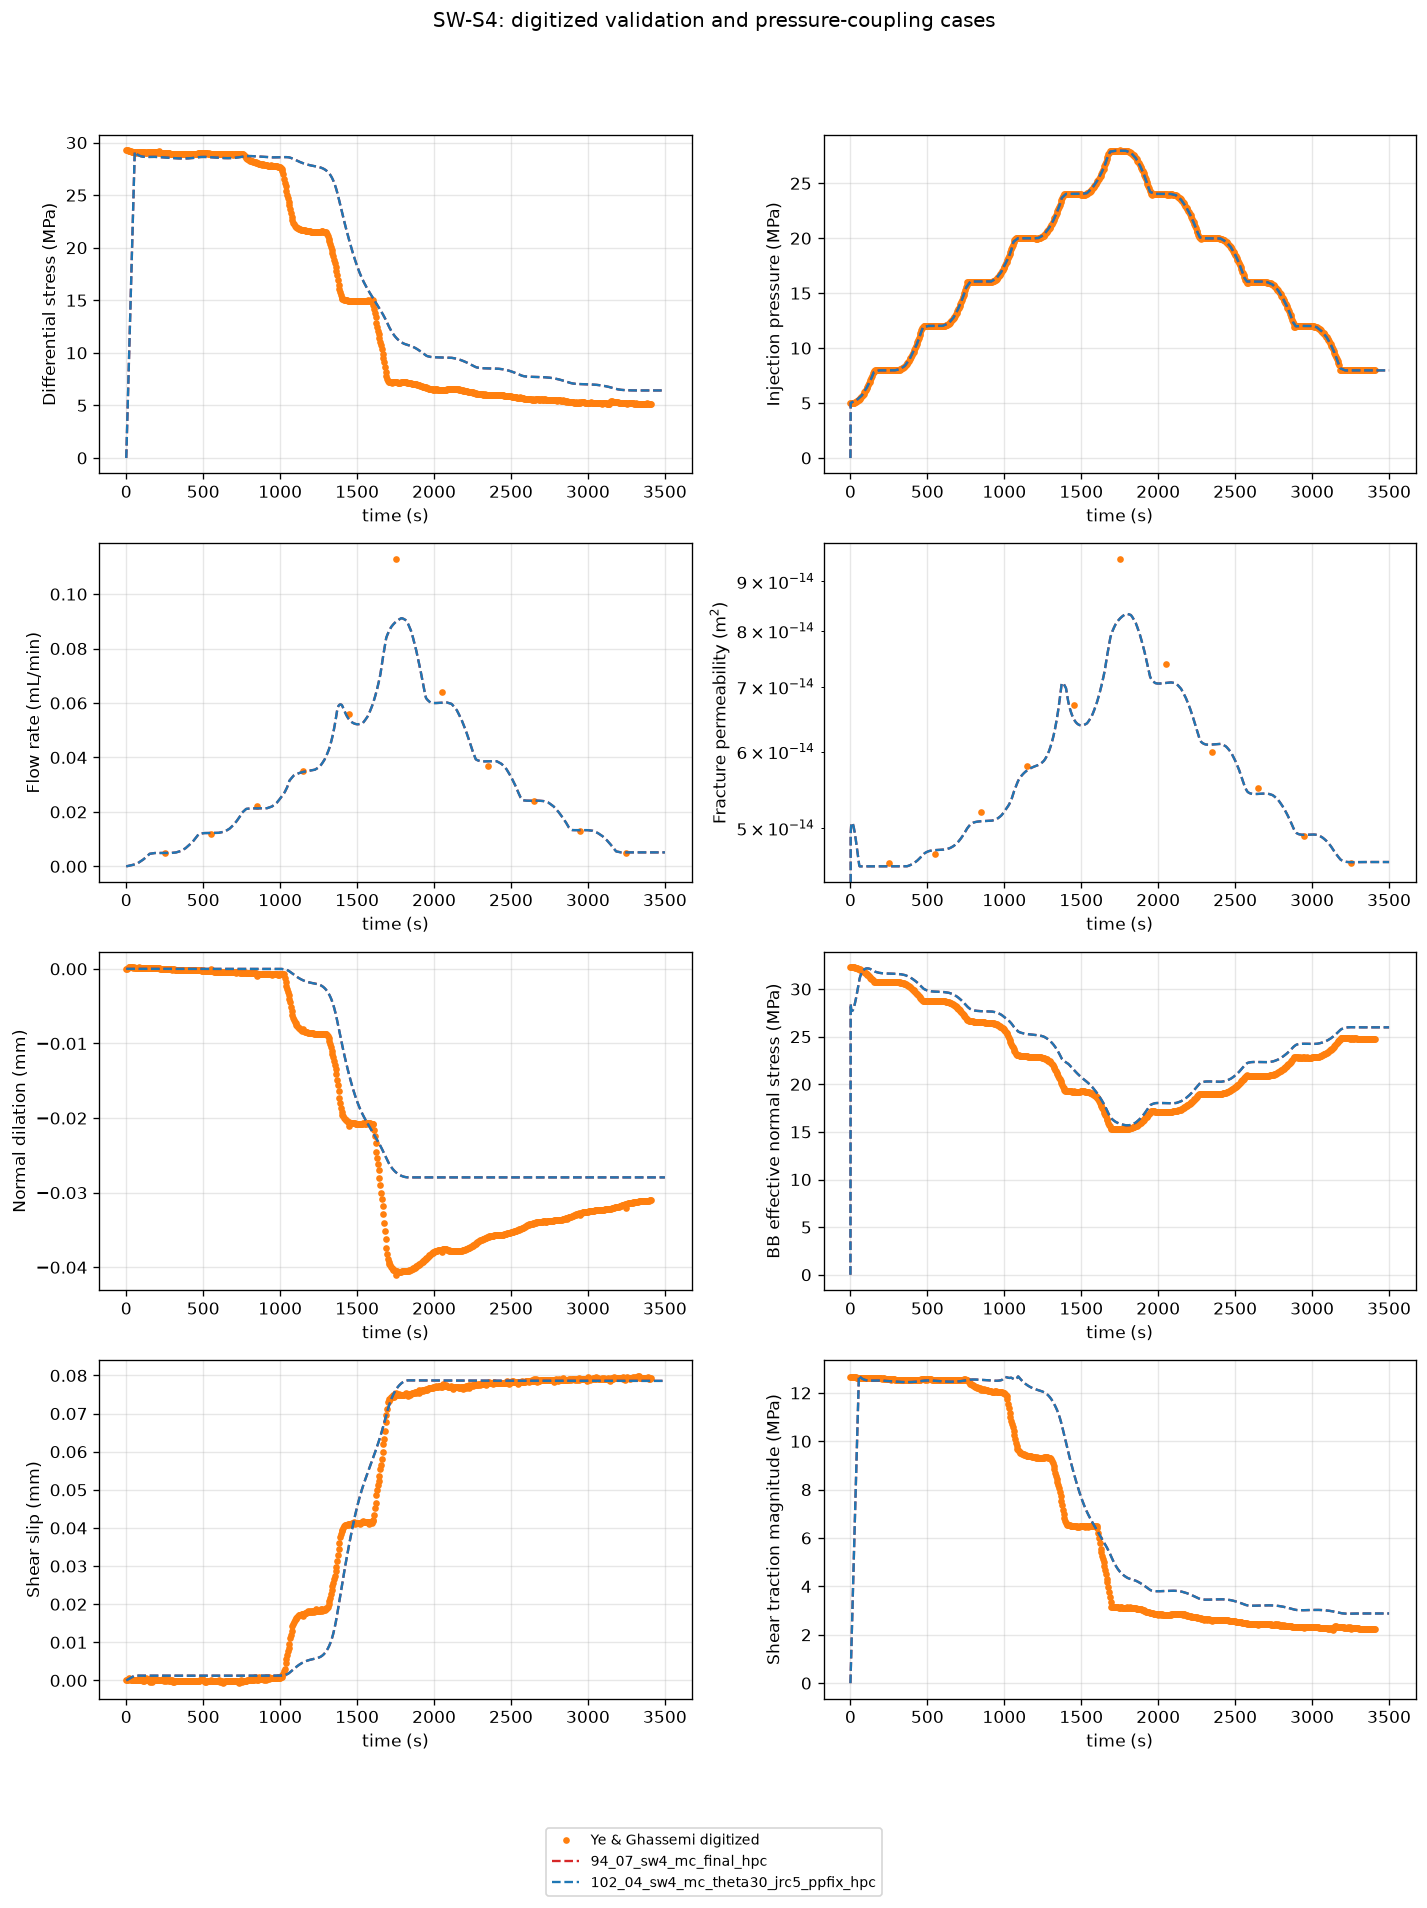

In [205]:
def get_series(data, alias, *, default=np.nan):
    series, column = first_series(data['df'], alias)
    if series is None:
        return pd.Series(default, index=data['df'].index), None
    return series, column


def plot_case_lines(ax, alias_or_column, *, scale=1.0, label_suffix='', allow_missing=True):
    plotted = False
    for name, data in loaded_cases.items():
        df = data['df']
        if alias_or_column in df.columns:
            y = pd.to_numeric(df[alias_or_column], errors='coerce') * scale
            source = alias_or_column
        else:
            y, source = first_series(df, alias_or_column)
            if y is not None:
                y = y * scale
        if y is None:
            if not allow_missing:
                print(f'{name}: missing {alias_or_column}')
            continue
        cfg = data['cfg']
        ax.plot(df['time'], y, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}{label_suffix}')
        plotted = True
    return plotted


def place_bottom_legend(fig, axes=None, *, ncol=None, bottom=0.12, top=0.98):
    if axes is None:
        axes = fig.axes
    axes = np.ravel(np.atleast_1d(axes)).tolist()

    legend_items = {}
    for ax in axes:
        existing_legend = ax.get_legend()
        if existing_legend is not None:
            existing_legend.remove()
        handles, labels = ax.get_legend_handles_labels()
        for handle, label in zip(handles, labels):
            if label and not label.startswith('_') and label not in legend_items:
                legend_items[label] = handle

    if legend_items:
        if ncol is None:
            ncol = min(4, len(legend_items))
        fig.legend(
            list(legend_items.values()),
            list(legend_items.keys()),
            loc='lower center',
            bbox_to_anchor=(0.5, 0.01),
            ncol=ncol,
            fontsize='small',
            frameon=True,
        )
    fig.tight_layout(rect=(0, bottom, 1, top))


def plot_metric(ax, metric, ylabel, *, yscale=None):
    plotted = plot_case_lines(ax, metric)
    ax.set_xlabel('time (s)')
    ax.set_ylabel(ylabel)
    if yscale:
        ax.set_yscale(yscale)
    return plotted

# Paper-style validation comparison retained from the previous workflow, now for every loaded case.
panel_specs = [
    ('differential_stress', 'differential_stress_mpa', 'Differential stress (MPa)'),
    ('injection_pressure', 'injection_pressure_pa', 'Injection pressure (MPa)', 1.0e-6),
    ('flow_rate', 'flow_rate_ml_min', 'Flow rate (mL/min)'),
    ('frac_perm', 'fracture_permeability_m2', 'Fracture permeability (m$^2$)', 1.0, 'log'),
    ('normal_dilation', 'normal_dilation_mm', 'Normal dilation (mm)'),
    ('normal_stress', 'bb_effective_normal_stress_pa', 'BB effective normal stress (MPa)', 1.0e-6),
    ('shear_slip', 'shear_slip_mm', 'Shear slip (mm)'),
    ('shear_stress', 'shear_traction_magnitude_pa', 'Shear traction magnitude (MPa)', 1.0e-6),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for ax, spec in zip(axes.flat, panel_specs):
    key, alias, ylabel = spec[:3]
    scale = spec[3] if len(spec) > 3 else 1.0
    yscale = spec[4] if len(spec) > 4 else None
    v = validation.get(key)
    if v is not None and not v.empty:
        ax.plot(v['time_s'], v['value'], 'o', ms=3, color='tab:orange', label='Ye & Ghassemi digitized')
    plot_case_lines(ax, alias, scale=scale)
    ax.set_xlabel('time (s)')
    ax.set_ylabel(ylabel)
    if yscale:
        ax.set_yscale(yscale)
fig.suptitle('SW-S4: digitized validation and pressure-coupling cases', y=0.995)
place_bottom_legend(fig, axes, ncol=1, bottom=0.08, top=0.96)
fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_validation_comparison.png', bbox_inches='tight')
plt.show()

In [206]:
# --- Table-2 promotion gates (2026-08-13) -----------------------------------------------------
# From SW4_67_FINAL_FOUR/BACK_ANALYSIS_AND_FINAL_SELECTION.md gate #4: "Require final slip within
# about 0.002 mm and dilation minimum/end within about 0.003/0.002 mm before promotion." Extended
# here with shear traction and reaction-based differential stress (informational only -- no
# established gate width for these two, so they are reported but not PASS/FAIL graded; use
# q_reaction, not q_raw, per the sigma3 cross-check above).

TABLE2_TARGETS = {
    'final_shear_slip_mm': 0.0794,
    'dilation_min_mm': -0.0409,
    'dilation_end_mm': -0.0314,
    'final_shear_traction_MPa': 2.20,
    'final_differential_stress_MPa': 5.14,
}
GATE_WIDTHS = {
    'final_shear_slip_mm': 0.002,
    'dilation_min_mm': 0.003,
    'dilation_end_mm': 0.002,
}

gate_rows = []
for case_name, data in loaded_cases.items():
    df = data['df']
    slip = df['czm_shear_slip_mm_pp'] if 'czm_shear_slip_mm_pp' in df.columns else None
    dil = df['czm_normal_dilation_paper_mm_pp'] if 'czm_normal_dilation_paper_mm_pp' in df.columns else None
    tau = df['shear_traction_magnitude_pa'] if 'shear_traction_magnitude_pa' in df.columns else None
    q_reaction = df['differential_stress_reaction_mpa_pp'] if 'differential_stress_reaction_mpa_pp' in df.columns else None

    final_slip = float(slip.iloc[-1]) if slip is not None else np.nan
    dil_min = float(dil.min()) if dil is not None else np.nan
    dil_end = float(dil.iloc[-1]) if dil is not None else np.nan
    final_tau = float(tau.iloc[-1]) / 1.0e6 if tau is not None else np.nan
    final_q = float(q_reaction.iloc[-1]) if q_reaction is not None else np.nan

    row = {
        'case': case_name,
        'final_shear_slip_mm': final_slip,
        'slip_error_mm': final_slip - TABLE2_TARGETS['final_shear_slip_mm'] if np.isfinite(final_slip) else np.nan,
        'dilation_min_mm': dil_min,
        'dilation_min_error_mm': dil_min - TABLE2_TARGETS['dilation_min_mm'] if np.isfinite(dil_min) else np.nan,
        'dilation_end_mm': dil_end,
        'dilation_end_error_mm': dil_end - TABLE2_TARGETS['dilation_end_mm'] if np.isfinite(dil_end) else np.nan,
        'final_shear_traction_MPa': final_tau,
        'shear_traction_error_MPa': final_tau - TABLE2_TARGETS['final_shear_traction_MPa'] if np.isfinite(final_tau) else np.nan,
        'final_differential_stress_reaction_MPa': final_q,
        'differential_stress_error_MPa': final_q - TABLE2_TARGETS['final_differential_stress_MPa'] if np.isfinite(final_q) else np.nan,
    }
    row['slip_gate_PASS'] = bool(np.isfinite(row['slip_error_mm']) and abs(row['slip_error_mm']) <= GATE_WIDTHS['final_shear_slip_mm'])
    row['dilation_min_gate_PASS'] = bool(np.isfinite(row['dilation_min_error_mm']) and abs(row['dilation_min_error_mm']) <= GATE_WIDTHS['dilation_min_mm'])
    row['dilation_end_gate_PASS'] = bool(np.isfinite(row['dilation_end_error_mm']) and abs(row['dilation_end_error_mm']) <= GATE_WIDTHS['dilation_end_mm'])
    row['all_established_gates_PASS'] = bool(row['slip_gate_PASS'] and row['dilation_min_gate_PASS'] and row['dilation_end_gate_PASS'])
    gate_rows.append(row)

gates = pd.DataFrame(gate_rows)
print('Table-2 promotion gates (final-state comparison; note: running jobs show partial-trajectory values, not final)')
with pd.option_context('display.max_columns', None, 'display.width', 200):
    display(gates)


Table-2 promotion gates (final-state comparison; note: running jobs show partial-trajectory values, not final)


,case,final_shear_slip_mm,slip_error_mm,dilation_min_mm,dilation_min_error_mm,dilation_end_mm,dilation_end_error_mm,final_shear_traction_MPa,shear_traction_error_MPa,final_differential_stress_reaction_MPa,differential_stress_error_MPa,slip_gate_PASS,dilation_min_gate_PASS,dilation_end_gate_PASS,all_established_gates_PASS
0,94_07_sw4_mc_final_hpc,0.078581,-0.000819,-0.02795,0.01295,-0.02795,0.00345,2.880936,0.680936,6.422231,1.282231,True,False,False,False
1,102_04_sw4_mc_theta30_jrc5_ppfix_hpc,0.078581,-0.000819,-0.02795,0.01295,-0.02795,0.00345,2.881018,0.681018,6.422215,1.282215,True,False,False,False


## Ye & Ghassemi (2018) Table 2 hold-stage comparison

This benchmark reads the sample-specific Table 2 CSV from
`../Extracted_Data/Table2_4_Sample_CSV_Files`. Each numerical history is sampled at
the 11 established experimental hold-stage times and compared against the published
loading and unloading branches as a function of injection pressure. A missing or
unreached simulation stage remains blank. The final table reports model-minus-Table-2
RMSE, MAE, and bias separately for every reported quantity.


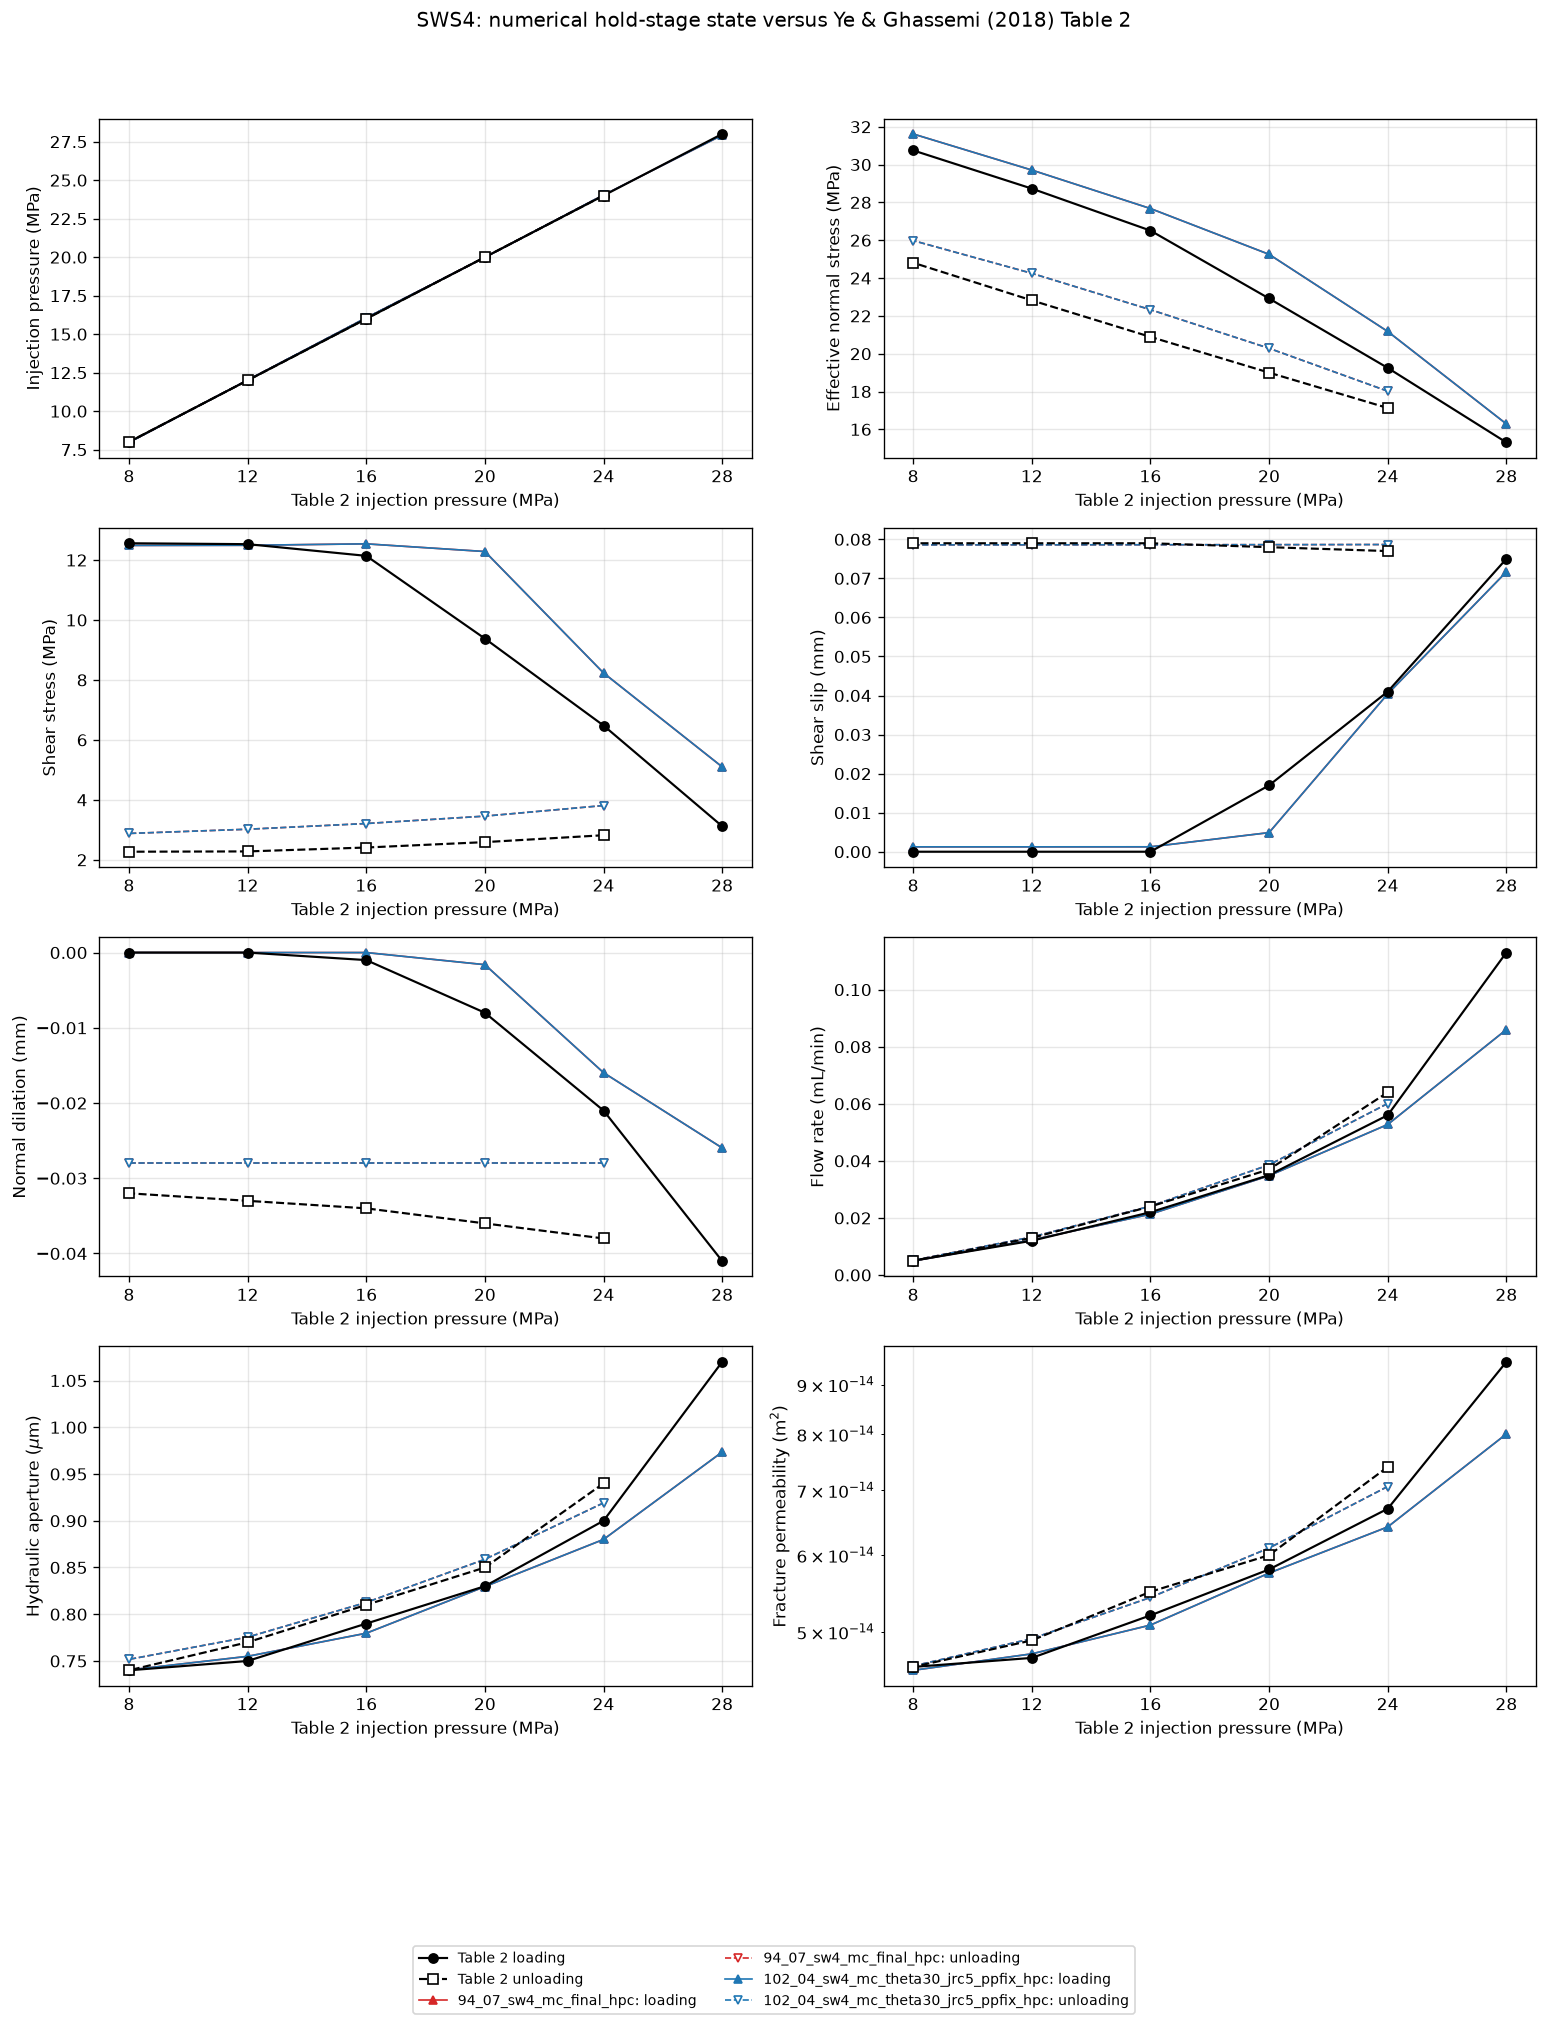

Table 2 source: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/Extracted_Data/Table2_4_Sample_CSV_Files/SW-S4_Table2.csv
Table 2 comparison figure: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/SWS4/Ye2018_SWS4_Table2_hold_stage_comparison.png


,case,quantity,model_source,unit,stages_compared,rmse,mae,bias
0,94_07_sw4_mc_final_hpc,injection_pressure,injection_pressure_pp,MPa,11,4.090436e-02,3.452075e-02,5.618585e-03
1,94_07_sw4_mc_final_hpc,effective_normal_stress,bb_effective_normal_stress_pp,MPa,11,1.385722e+00,1.315319e+00,1.315319e+00
2,94_07_sw4_mc_final_hpc,shear_stress,shear_traction_magnitude_pa,MPa,11,1.310388e+00,1.014153e+00,9.940622e-01
3,94_07_sw4_mc_final_hpc,shear_slip,czm_shear_slip_mm_pp,mm,11,3.889341e-03,2.117756e-03,-1.015011e-03
4,94_07_sw4_mc_final_hpc,normal_dilation,czm_normal_dilation_paper_mm_pp,mm,11,6.989622e-03,5.518478e-03,5.518478e-03
5,94_07_sw4_mc_final_hpc,flow_rate,flow_rate_validation_ml_min_pp,mL/min,11,8.304323e-03,3.417844e-03,-2.974354e-03
6,94_07_sw4_mc_final_hpc,hydraulic_aperture,hydraulic_aperture_pp,$\mu$m,11,3.092668e-02,1.654017e-02,-1.037887e-02
7,94_07_sw4_mc_final_hpc,fracture_permeability,fracture_permeability_pp,m$^2$,11,4.739718e-15,2.340857e-15,-2.015045e-15
8,102_04_sw4_mc_theta30_jrc5_ppfix_hpc,injection_pressure,injection_pressure_pp,MPa,11,4.090436e-02,3.452075e-02,5.618585e-03
9,102_04_sw4_mc_theta30_jrc5_ppfix_hpc,effective_normal_stress,bb_effective_normal_stress_pp,MPa,11,1.385719e+00,1.315315e+00,1.315315e+00


In [207]:
# Table 2 source and hold-stage timing (same time basis as the plots above).
TABLE2_FILENAME = 'SW-S4_Table2.csv'
TABLE2_PATH = BASE.parent / 'Extracted_Data' / 'Table2_4_Sample_CSV_Files' / TABLE2_FILENAME
TABLE2_HOLD_TIMES_S = np.array([252.5, 570.5, 849.3, 1157.5, 1471.4, 1703.9, 2046.8, 2359.3, 2668.7, 2968.5, 3293.5], dtype=float)

if not TABLE2_PATH.is_file():
    raise FileNotFoundError(f'Table 2 CSV not found: {TABLE2_PATH}')

table2 = pd.read_csv(TABLE2_PATH)
required_table2_columns = {
    'hold_stage_index', 'segment', 'injection_pressure_MPa',
    'flow_rate_ml_min', 'normal_dilation_mm', 'shear_slip_mm',
    'effective_normal_stress_MPa', 'shear_stress_MPa',
    'hydraulic_aperture_m', 'fracture_permeability_m2',
}
missing_table2_columns = sorted(required_table2_columns.difference(table2.columns))
if missing_table2_columns:
    raise KeyError(f'{TABLE2_PATH.name}: missing columns {missing_table2_columns}')
if len(table2) != len(TABLE2_HOLD_TIMES_S):
    raise ValueError(
        f'{TABLE2_PATH.name}: expected {len(TABLE2_HOLD_TIMES_S)} hold stages, '
        f'found {len(table2)}'
    )

table2 = table2.copy().sort_values('hold_stage_index').reset_index(drop=True)
table2['hold_time_s'] = TABLE2_HOLD_TIMES_S
table2['branch'] = table2['segment'].str.strip().str.lower()

# key: (Table 2 column, model alias/column, model scale, displayed scale, label, unit)
TABLE2_PANEL_SPECS = {
    'injection_pressure': (
        'injection_pressure_MPa', 'injection_pressure_pa', 1.0e-6, 1.0,
        'Injection pressure', 'MPa',
    ),
    'effective_normal_stress': (
        'effective_normal_stress_MPa', 'bb_effective_normal_stress_pa', 1.0e-6, 1.0,
        'Effective normal stress', 'MPa',
    ),
    'shear_stress': (
        'shear_stress_MPa', 'shear_traction_magnitude_pa', 1.0e-6, 1.0,
        'Shear stress', 'MPa',
    ),
    'shear_slip': (
        'shear_slip_mm', 'shear_slip_mm', 1.0, 1.0,
        'Shear slip', 'mm',
    ),
    'normal_dilation': (
        'normal_dilation_mm', 'normal_dilation_mm', 1.0, 1.0,
        'Normal dilation', 'mm',
    ),
    'flow_rate': (
        'flow_rate_ml_min', 'flow_rate_ml_min', 1.0, 1.0,
        'Flow rate', 'mL/min',
    ),
    'hydraulic_aperture': (
        'hydraulic_aperture_m', 'hydraulic_aperture_m', 1.0, 1.0e6,
        'Hydraulic aperture', r'$\mu$m',
    ),
    'fracture_permeability': (
        'fracture_permeability_m2', 'fracture_permeability_m2', 1.0, 1.0,
        'Fracture permeability', r'm$^2$',
    ),
}


def table2_model_series(data, alias_or_column, scale=1.0):
    df = data['df']
    if alias_or_column in df.columns:
        values = pd.to_numeric(df[alias_or_column], errors='coerce') * scale
        source = alias_or_column
    else:
        values, source = first_series(df, alias_or_column, case_name=data['name'])
        if values is not None:
            values = values * scale
    if values is None:
        return None, source
    valid = pd.DataFrame({
        'time': pd.to_numeric(df['time'], errors='coerce'),
        'value': pd.to_numeric(values, errors='coerce'),
    }).dropna().sort_values('time').drop_duplicates('time', keep='last')
    return valid, source


def sample_table2_holds(data, alias_or_column, scale=1.0):
    valid, source = table2_model_series(data, alias_or_column, scale)
    if valid is None or valid.empty:
        return np.full(len(TABLE2_HOLD_TIMES_S), np.nan), source
    sampled = np.interp(
        TABLE2_HOLD_TIMES_S,
        valid['time'].to_numpy(float),
        valid['value'].to_numpy(float),
        left=np.nan,
        right=np.nan,
    )
    return sampled, source


table2_case_frames = {}
table2_metric_rows = []
for case_name, data in loaded_cases.items():
    comparison = table2[[
        'hold_stage_index', 'branch', 'injection_pressure_MPa', 'hold_time_s'
    ]].copy()
    for quantity, spec in TABLE2_PANEL_SPECS.items():
        table_column, model_alias, model_scale, display_scale, _label, unit = spec
        model_values, source = sample_table2_holds(data, model_alias, model_scale)
        paper_values = pd.to_numeric(table2[table_column], errors='coerce').to_numpy(float)
        model_values = model_values * display_scale
        paper_values = paper_values * display_scale
        comparison[f'{quantity}_model'] = model_values
        comparison[f'{quantity}_table2'] = paper_values
        comparison[f'{quantity}_error'] = model_values - paper_values
        valid_error = comparison[f'{quantity}_error'].dropna().to_numpy(float)
        if len(valid_error):
            table2_metric_rows.append({
                'case': case_name,
                'quantity': quantity,
                'model_source': source or 'unavailable',
                'unit': unit,
                'stages_compared': int(len(valid_error)),
                'rmse': float(np.sqrt(np.mean(valid_error**2))),
                'mae': float(np.mean(np.abs(valid_error))),
                'bias': float(np.mean(valid_error)),
            })
    table2_case_frames[case_name] = comparison

fig, axes = plt.subplots(4, 2, figsize=(13, 17), squeeze=False)
branch_styles = {
    'loading': dict(marker='^', linestyle='-'),
    'unloading': dict(marker='v', linestyle='--'),
}
case_colors = {
    case_name: data['cfg'].get('color', f'C{index}')
    for index, (case_name, data) in enumerate(loaded_cases.items())
}

for ax, (quantity, spec) in zip(axes.flat, TABLE2_PANEL_SPECS.items()):
    table_column, _model_alias, _model_scale, display_scale, label, unit = spec
    for branch, paper_marker, paper_fill in (
        ('loading', 'o', 'black'), ('unloading', 's', 'white')
    ):
        paper = table2.loc[table2['branch'].eq(branch)]
        ax.plot(
            paper['injection_pressure_MPa'],
            pd.to_numeric(paper[table_column], errors='coerce') * display_scale,
            color='black', marker=paper_marker, markerfacecolor=paper_fill,
            linestyle='-' if branch == 'loading' else '--', linewidth=1.3,
            markersize=5.5, label=f'Table 2 {branch}', zorder=6,
        )
    for case_name, comparison in table2_case_frames.items():
        color = case_colors[case_name]
        for branch, style in branch_styles.items():
            model = comparison.loc[comparison['branch'].eq(branch)]
            ax.plot(
                model['injection_pressure_MPa'], model[f'{quantity}_model'],
                color=color, markerfacecolor=color if branch == 'loading' else 'white',
                markeredgecolor=color, linewidth=1.0, markersize=5,
                label=f'{case_name}: {branch}', **style,
            )
    ax.set_xlabel('Table 2 injection pressure (MPa)')
    ax.set_ylabel(f'{label} ({unit})')
    ax.set_xticks([8, 12, 16, 20, 24, 28])
    if quantity == 'fracture_permeability':
        ax.set_yscale('log')

fig.suptitle(
    f'{SAMPLE}: numerical hold-stage state versus Ye & Ghassemi (2018) Table 2',
    y=0.995,
)
place_bottom_legend(fig, axes, ncol=2, bottom=0.14, top=0.97)
table2_figure_path = BASE / f'Ye2018_{SAMPLE}_Table2_hold_stage_comparison.png'
fig.savefig(table2_figure_path, bbox_inches='tight')
plt.show()

table2_metrics = pd.DataFrame(table2_metric_rows)
print(f'Table 2 source: {TABLE2_PATH}')
print(f'Table 2 comparison figure: {table2_figure_path}')
with pd.option_context('display.max_rows', 200, 'display.max_columns', None):
    display(table2_metrics)


In [208]:
# # 1. Accepted timestep versus time, with former-failure zoom.
# fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
# plot_metric(axes[0], 'accepted_dt_s', 'accepted dt (s)', yscale='log')
# axes[0].set_title('Accepted timestep')
# plot_metric(axes[1], 'accepted_dt_s', 'accepted dt (s)', yscale='log')
# axes[1].set_xlim(*NEAR_FAILURE_WINDOW_S)
# axes[1].axvline(FAILURE_TIME_S, color='k', linewidth=1, alpha=0.5)
# axes[1].set_title('Zoom: 1500-1650 s')
# place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
# fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_dt.png', bbox_inches='tight')
# plt.show()

# # 2. Injection pressure and interface pore pressure.
# fig, ax = plt.subplots(figsize=(8, 4))
# for name, data in loaded_cases.items():
#     df = data['df']
#     cfg = data['cfg']
#     inj, inj_col = first_series(df, 'injection_pressure_pa')
#     pif, pif_col = first_series(df, 'interface_pore_pressure_pa')
#     if inj is not None:
#         ax.plot(df['time'], inj / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.5, label=f'{name}: injection')
#     if pif is not None:
#         ax.plot(df['time'], pif / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: interface pore pressure')
# ax.set_xlabel('time (s)')
# ax.set_ylabel('pressure (MPa)')
# place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
# fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_pressures.png', bbox_inches='tight')
# plt.show()

# # 3. Contact normal stress and BB effective normal stress.
# fig, ax = plt.subplots(figsize=(8, 4))
# for name, data in loaded_cases.items():
#     df = data['df']
#     cfg = data['cfg']
#     normal, _ = first_series(df, 'bb_normal_stress_pa')
#     effective, _ = first_series(df, 'bb_effective_normal_stress_pa')
#     if normal is not None:
#         ax.plot(df['time'], normal / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}: BB normal')
#     if effective is not None:
#         ax.plot(df['time'], effective / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: BB effective normal')
# ax.set_xlabel('time (s)')
# ax.set_ylabel('stress (MPa)')
# place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
# fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_normal_stress.png', bbox_inches='tight')
# plt.show()

In [209]:
# # 4. Shear traction magnitude and BB shear-strength limit.
# fig, ax = plt.subplots(figsize=(8, 4))
# for name, data in loaded_cases.items():
#     df = data['df']
#     cfg = data['cfg']
#     shear = df.get('shear_traction_magnitude_pa')
#     limit_tau, _ = first_series(df, 'bb_limit_tau_pa')
#     if shear is not None:
#         ax.plot(df['time'], shear / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}: shear traction')
#     if limit_tau is not None:
#         ax.plot(df['time'], limit_tau / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: BB limit')
# ax.set_xlabel('time (s)')
# ax.set_ylabel('shear stress / strength (MPa)')
# place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
# fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_shear_limit.png', bbox_inches='tight')
# plt.show()

# # 5. Shear-strength margin, with former-failure zoom.
# fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
# plot_metric(axes[0], 'strength_margin_pa', 'BB strength margin (Pa)')
# axes[0].axhline(0.0, color='k', linewidth=1, alpha=0.5)
# axes[0].set_title('Strength margin')
# plot_metric(axes[1], 'strength_margin_pa', 'BB strength margin (Pa)')
# axes[1].set_xlim(*NEAR_FAILURE_WINDOW_S)
# axes[1].axhline(0.0, color='k', linewidth=1, alpha=0.5)
# axes[1].axvline(FAILURE_TIME_S, color='k', linewidth=1, alpha=0.5)
# axes[1].set_title('Zoom: 1500-1650 s')
# place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
# fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_strength_margin.png', bbox_inches='tight')
# plt.show()

# # 6. Hydraulic aperture.
# fig, ax = plt.subplots(figsize=(8, 4))
# plot_metric(ax, 'hydraulic_aperture_m', 'hydraulic aperture (m)')
# place_bottom_legend(fig, ax, ncol=1, bottom=0.25)
# fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_aperture.png', bbox_inches='tight')
# plt.show()

# # 7. Fracture permeability and transmissivity.
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# plot_metric(axes[0], 'fracture_permeability_m2', 'fracture permeability (m$^2$)', yscale='log')
# plot_metric(axes[1], 'fracture_transmissivity_m3_pa_s', 'fracture transmissivity (m$^3$/(Pa s))', yscale='log')
# place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
# fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_hydraulic_properties.png', bbox_inches='tight')
# plt.show()

# # 8. Nonlinear iterations or solver diagnostics, if available.
# fig, ax = plt.subplots(figsize=(8, 4))
# plotted_iterations = plot_metric(ax, 'nonlinear_iterations', 'nonlinear iterations')
# if plotted_iterations:
#     place_bottom_legend(fig, ax, ncol=1, bottom=0.25)
#     fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_nonlinear_iterations.png', bbox_inches='tight')
#     plt.show()
# else:
#     plt.close(fig)
#     print('No nonlinear-iteration postprocessor column was available in the loaded CSV files.')

In [210]:
# # Quantitative mismatch metrics and slip-onset zoom.
# def interp_series(time, values, query_time):
#     valid = pd.DataFrame({'time': time, 'value': values}).dropna().sort_values('time')
#     if valid.empty or query_time < valid['time'].iloc[0] or query_time > valid['time'].iloc[-1]:
#         return np.nan
#     return float(np.interp(query_time, valid['time'], valid['value']))

# metric_specs = {
#     'differential_stress': ('differential_stress_mpa', 1.0),
#     'injection_pressure': ('injection_pressure_pa', 1.0e-6),
#     'flow_rate': ('flow_rate_ml_min', 1.0),
#     'frac_perm': ('fracture_permeability_m2', 1.0),
#     'normal_dilation': ('normal_dilation_mm', 1.0),
#     'normal_stress': ('bb_effective_normal_stress_pa', 1.0e-6),
#     'shear_slip': ('shear_slip_mm', 1.0),
#     'shear_stress': ('shear_traction_magnitude_pa', 1.0e-6),
# }

# metric_rows = []
# for case_name, data in loaded_cases.items():
#     df = data['df']
#     for val_key, (alias, scale) in metric_specs.items():
#         vdf = validation.get(val_key)
#         if vdf is None or vdf.empty:
#             continue
#         if alias in df.columns:
#             model_values = df[alias] * scale
#         else:
#             series, _ = first_series(df, alias)
#             if series is None:
#                 continue
#             model_values = series * scale
#         errors = []
#         for t_val, y_val in zip(vdf['time_s'], vdf['value']):
#             y_model = interp_series(df['time'], model_values, t_val)
#             if np.isfinite(y_model):
#                 errors.append(y_model - y_val)
#         if errors:
#             errors = np.asarray(errors, dtype=float)
#             metric_rows.append({
#                 'case': case_name,
#                 'quantity': val_key,
#                 'n': int(len(errors)),
#                 'rmse': float(np.sqrt(np.mean(errors**2))),
#                 'mae': float(np.mean(np.abs(errors))),
#                 'bias': float(np.mean(errors)),
#             })

# metrics = pd.DataFrame(metric_rows)
# with pd.option_context('display.max_rows', 200, 'display.max_columns', None):
#     display(metrics)

# def onset_time_from_xy(time, values, *, baseline_end=900.0, threshold=0.002, direction='increase'):
#     xy = pd.DataFrame({'time': time, 'value': values}).dropna().sort_values('time')
#     early = xy.loc[xy['time'] <= baseline_end, 'value']
#     baseline = float(early.median()) if not early.empty else float(xy['value'].iloc[0])
#     for _, row in xy.loc[xy['time'] >= baseline_end].iterrows():
#         delta = row['value'] - baseline
#         if direction == 'increase' and delta >= threshold:
#             return float(row['time'])
#         if direction == 'decrease' and -delta >= threshold:
#             return float(row['time'])
#     return np.nan

# onset_rows = []
# val_slip_onset = onset_time_from_xy(validation['shear_slip']['time_s'], validation['shear_slip']['value'], threshold=0.002, direction='increase')
# val_dilation_onset = onset_time_from_xy(validation['normal_dilation']['time_s'], validation['normal_dilation']['value'], threshold=0.002, direction='decrease')
# val_stress_drop_onset = onset_time_from_xy(validation['differential_stress']['time_s'], validation['differential_stress']['value'], threshold=2.0, direction='decrease')
# for case_name, data in loaded_cases.items():
#     df = data['df']
#     slip, _ = first_series(df, 'shear_slip_mm')
#     dilation, _ = first_series(df, 'normal_dilation_mm')
#     diff, _ = first_series(df, 'differential_stress_mpa')
#     onset_rows.append({
#         'case': case_name,
#         'validation_slip_onset_s': val_slip_onset,
#         'model_slip_onset_s': onset_time_from_xy(df['time'], slip, threshold=0.002, direction='increase') if slip is not None else np.nan,
#         'validation_dilation_onset_s': val_dilation_onset,
#         'model_dilation_onset_s': onset_time_from_xy(df['time'], dilation, threshold=0.002, direction='decrease') if dilation is not None else np.nan,
#         'validation_stress_drop_onset_s': val_stress_drop_onset,
#         'model_stress_drop_onset_s': onset_time_from_xy(df['time'], diff, threshold=2.0, direction='decrease') if diff is not None else np.nan,
#     })
# onsets = pd.DataFrame(onset_rows)
# display(onsets)

# fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
# zoom = (900, 1250)
# plot_items = [
#     ('shear_slip', 'shear_slip_mm', 'Shear slip (mm)'),
#     ('normal_dilation', 'normal_dilation_mm', 'Normal dilation (mm)'),
#     ('differential_stress', 'differential_stress_mpa', 'Differential stress (MPa)'),
# ]
# for ax, (val_key, alias, ylabel) in zip(axes, plot_items):
#     vdf = validation[val_key]
#     ax.plot(vdf['time_s'], vdf['value'], 'o', ms=3, color='tab:orange', label='Ye & Ghassemi digitized')
#     plot_case_lines(ax, alias)
#     ax.set_xlim(*zoom)
#     ax.set_ylabel(ylabel)
# axes[-1].set_xlabel('time (s)')
# fig.suptitle('Slip-onset zoom')
# place_bottom_legend(fig, axes, ncol=1, bottom=0.12, top=0.94)
# fig.savefig(BASE / 'Ye2018_SW4_pressure_coupling_slip_onset_zoom.png', bbox_inches='tight')
# plt.show()

In [211]:
# def interp_at_time(data, column, time_s):
#     df = data['df']
#     if column not in df.columns or df[column].notna().sum() < 2:
#         return np.nan
#     valid = df[['time', column]].dropna()
#     if valid.empty or time_s < valid['time'].min() or time_s > valid['time'].max():
#         return np.nan
#     return float(np.interp(time_s, valid['time'], valid[column]))


# def select_corrected_case():
#     if 'Final selected corrected candidate' in loaded_cases:
#         return loaded_cases['Final selected corrected candidate'], 'final selected corrected candidate'
#     for name, data in loaded_cases.items():
#         if data['cfg'].get('kind', '').startswith('corrected'):
#             return data, 'available corrected fallback case'
#     return None, 'no corrected case available'

# legacy = loaded_cases.get('Legacy double weakening')
# corrected, corrected_label = select_corrected_case()

# print('Automated conclusion')
# print('--------------------')
# if corrected is None:
#     print('No corrected result CSV was loaded, so the pressure-coupling correction cannot be evaluated from results in this notebook run.')
# else:
#     csum = summary.loc[summary['case'] == corrected['name']].iloc[0]
#     print(f'Corrected case evaluated: {corrected["name"]} ({corrected_label}).')
#     print(f"Passed t = {FAILURE_TIME_S:.2f} s: {bool(csum['passed_1588_22_s'])}.")
#     print(f"Reached intended end time {csum['intended_end_time_s']:.6g} s: {bool(csum['reached_intended_end_time'])} (final t = {csum['final_time_s']:.6g} s).")
#     print(f"Minimum accepted dt in 1500-1650 s: {csum['min_dt_1500_1650_s']:.6g} s.")

#     corr_eff = interp_at_time(corrected, 'bb_effective_normal_stress_pp', min(FAILURE_TIME_S, corrected['df']['time'].max())) / 1.0e6
#     corr_margin = corrected['df'].loc[corrected['df']['time'].between(*NEAR_FAILURE_WINDOW_S), 'strength_margin_pa'].min()
#     print(f'Corrected BB effective normal stress near former failure: {corr_eff:.6g} MPa.')
#     print(f'Corrected minimum strength margin in 1500-1650 s: {corr_margin:.6g} Pa.')

#     if legacy is not None:
#         lsum = summary.loc[summary['case'] == legacy['name']].iloc[0]
#         leg_eff = interp_at_time(legacy, 'bb_effective_normal_stress_pp', min(FAILURE_TIME_S, legacy['df']['time'].max())) / 1.0e6
#         leg_margin = legacy['df'].loc[legacy['df']['time'].between(*NEAR_FAILURE_WINDOW_S), 'strength_margin_pa'].min()
#         print(f'Legacy final time: {lsum["final_time_s"]:.6g} s; min dt in 1500-1650 s: {lsum["min_dt_1500_1650_s"]:.6g} s.')
#         print(f'Legacy BB effective normal stress near former failure: {leg_eff:.6g} MPa.')
#         print(f'Legacy minimum strength margin in 1500-1650 s: {leg_margin:.6g} Pa.')

#     evidence_supports_removal = bool(
#         csum['passed_1588_22_s']
#         and not csum['monitored_nan_or_inf']
#         and np.isfinite(csum['min_dt_1500_1650_s'])
#         and csum['min_dt_1500_1650_s'] > 1.0e-5
#     )
#     if corrected.get('csv_is_stale', False):
#         print('The final candidate CSV is older than the input deck; rerun the full transient before treating this as validation.')
#     if corrected['name'] != 'Final selected corrected candidate':
#         print('The final selected CSV was not present; this conclusion uses an existing corrected fallback result and is not final validation.')
#     print(f'Data support removing duplicate pore-pressure weakening: {evidence_supports_removal}.')

In [212]:
# # --- Sigma3 assumption cross-check (2026-08-13 back-analysis) ---------------------------------
# # differential_stress_mpa_pp (the column plotted above as "Differential stress (MPa)", and the one
# # fed into the metric/onset tables) is defined in the deck as (sigma1_pp - 30e6)*1e-6: it ASSUMES
# # sigma3 = 30 MPa exactly rather than measuring it (see the deck's own comment above that
# # postprocessor). When the true bulk sigma3 drifts from that assumption -- e.g. under a compliant
# # lateral BC as the fault opens/closes -- the naive channel silently absorbs the entire drift as
# # spurious "missing" differential stress. This cross-checks q_raw against three alternatives that
# # do not make the assumption: q_skeleton (uses the actually-measured domain-average sigma3),
# # q_biot (Biot-corrected using measured fracture pressure), and q_reaction (load-cell-style: uses
# # the top-surface reaction force and the deck's own confining_pressure parameter). The paper's own
# # definition (Sec. 2.3: sigma_d = sigma1 - sigma3, sigma3 = the apparatus's SET confining pressure,
# # sigma1 from the axial load cell) matches q_reaction's methodology, not a domain-averaged FEM
# # stress -- so q_reaction, not q_raw, is the physically appropriate comparator to Table 2. Found
# # on kernel_SV: sigma3_bulk had drifted to ~24.6 MPa (not 30), so q_raw read 1.63 MPa while
# # q_reaction read 5.78 MPa against a 5.14 MPa target.

# sigma3_cols = {
#     'sigma3_bulk_MPa': 'sigma3_bulk_mpa_pp',
#     'q_raw_assumes_sigma3=30_MPa': 'differential_stress_mpa_pp',
#     'q_skeleton_bulk_MPa': 'differential_stress_skeleton_bulk_pp',
#     'q_biot_corrected_MPa': 'differential_stress_biot_corrected_pp',
#     'q_reaction_load_cell_style_MPa': 'differential_stress_reaction_mpa_pp',
# }
# q_target = float(validation['differential_stress']['value'].iloc[-1]) if not validation['differential_stress'].empty else np.nan

# sigma3_check_rows = []
# for case_name, data in loaded_cases.items():
#     df = data['df']
#     final = df.iloc[-1]
#     row = {'case': case_name, 'final_time_s': float(final['time'])}
#     for label, col in sigma3_cols.items():
#         row[label] = float(final[col]) if col in df.columns else np.nan
#     row['sigma3_drift_from_30MPa'] = row['sigma3_bulk_MPa'] - 30.0 if np.isfinite(row['sigma3_bulk_MPa']) else np.nan
#     row['table2_target_MPa'] = q_target
#     row['q_reaction_error_pct'] = (
#         (row['q_reaction_load_cell_style_MPa'] - q_target) / q_target * 100.0
#         if np.isfinite(row['q_reaction_load_cell_style_MPa']) and q_target else np.nan
#     )
#     row['q_raw_error_pct'] = (
#         (row['q_raw_assumes_sigma3=30_MPa'] - q_target) / q_target * 100.0
#         if np.isfinite(row['q_raw_assumes_sigma3=30_MPa']) and q_target else np.nan
#     )
#     sigma3_check_rows.append(row)

# sigma3_check = pd.DataFrame(sigma3_check_rows)
# print('Sigma3 assumption cross-check (final row of each case)')
# with pd.option_context('display.max_columns', None, 'display.width', 160):
#     display(sigma3_check)


## Reproducibility notes

Run input validation from the repository root:

```bash
export PATH=/Users/saeedvdi/projects/miniforge/envs/moose/bin:$PATH
./orca-opt --check-input --allow-unused -i Examples/YeGhasemmi2018/SW4/Ye2018_SW4_hydraulic_pressure_traction_only.i
```

Run the full production corrected case with the original 32-rank batch settings from the SW4 directory:

```bash
sbatch Ye2018_SW4_hydraulic_pressure_traction_only.sh
```

or directly on a matching MPI environment:

```bash
cd /home/saeedvdi/links/projects/def-biaoli66/saeedvdi/projects/orca_3.0/Examples/YeGhasemmi2018/SW4
srun --mpi=pmi2 -n 32 /home/saeedvdi/links/projects/def-biaoli66/saeedvdi/projects/orca_3.0/orca-opt -i Ye2018_SW4_hydraulic_pressure_traction_only.i
```

After the CSV exists, re-execute this notebook. The automated conclusion cell will use `results/Ye2018_SW4_hydraulic_pressure_traction_only.csv` in preference to older corrected fallback CSVs.

## Individual validation and Table 2 figures for every HPC file

Every CSV in `results_csv_hpc*` is shown individually, including files that are not
enabled in the comparison dictionary above. Files are processed in filename order.
For each file, the time-history comparison against the digitized validation is drawn
first, immediately followed by the hold-stage comparison against Table 2. Only then
does the notebook move to the next HPC file.


In [213]:
# def discover_ordered_hpc_files():
#     """Discover every HPC CSV and return it in deterministic filename order."""
#     roots = [Path(HPC_RESULTS)]
#     files = {
#         path.resolve(): path.resolve()
#         for root in roots if root.is_dir()
#         for path in root.glob('*.csv')
#         if path.is_file()
#     }
#     return sorted(files.values(), key=lambda path: path.name.lower())


# def read_hpc_validation_file(path):
#     frame = pd.read_csv(path)
#     if 'time' not in frame.columns:
#         raise KeyError(f'{path.name}: missing required time column')
#     for column in frame.columns:
#         frame[column] = pd.to_numeric(frame[column], errors='coerce')
#     frame = (
#         frame.dropna(subset=['time'])
#         .sort_values('time')
#         .drop_duplicates('time', keep='last')
#         .reset_index(drop=True)
#     )

#     # Recreate the derived shear-traction channel used by the combined figure above.
#     tau1 = frame.get('czm_tau_1_pp')
#     tau2 = frame.get('czm_tau_2_pp')
#     if tau1 is not None and tau2 is not None:
#         frame['shear_traction_magnitude_pa'] = np.sqrt(tau1**2 + tau2**2)
#     elif tau1 is not None:
#         frame['shear_traction_magnitude_pa'] = tau1.abs()
#     elif 'shear_traction_magnitude_pa' not in frame:
#         shear_mpa, _ = first_series(frame, 'shear_stress_mpa', case_name=path.stem)
#         frame['shear_traction_magnitude_pa'] = (
#             shear_mpa.abs() * 1.0e6 if shear_mpa is not None else np.nan
#         )
#     return frame


# def individual_model_values(frame, alias_or_column, scale=1.0):
#     if alias_or_column in frame.columns:
#         return pd.to_numeric(frame[alias_or_column], errors='coerce') * scale
#     values, _ = first_series(frame, alias_or_column)
#     return None if values is None else values * scale


# def plot_individual_time_history(hpc_path, frame):
#     """First figure: the same eight validation panels, for one HPC file only."""
#     fig, axes = plt.subplots(4, 2, figsize=(12, 16), squeeze=False)
#     for ax, spec in zip(axes.flat, panel_specs):
#         validation_key, model_alias, ylabel = spec[:3]
#         scale = spec[3] if len(spec) > 3 else 1.0
#         yscale = spec[4] if len(spec) > 4 else None

#         measured = validation.get(validation_key)
#         if measured is not None and not measured.empty:
#             ax.plot(
#                 measured['time_s'], measured['value'], 'o', markersize=3,
#                 color='tab:orange', label='Ye & Ghassemi digitized', zorder=5,
#             )
#         model_values = individual_model_values(frame, model_alias, scale)
#         if model_values is not None:
#             ax.plot(
#                 frame['time'], model_values, color='tab:blue', linewidth=1.5,
#                 label=hpc_path.stem,
#             )
#         else:
#             ax.text(
#                 0.5, 0.5, f'Missing model channel: {model_alias}',
#                 transform=ax.transAxes, ha='center', va='center',
#             )
#         ax.set_xlabel('time (s)')
#         ax.set_ylabel(ylabel)
#         if yscale:
#             ax.set_yscale(yscale)

#     fig.suptitle(
#         f'{SAMPLE}: {hpc_path.name}\n'
#         'digitized validation and pressure-coupling result',
#         y=0.995,
#     )
#     place_bottom_legend(fig, axes, ncol=1, bottom=0.075, top=0.95)
#     plt.show()
#     plt.close(fig)
#     return fig


# def plot_individual_table2(hpc_path, frame):
#     """Second figure: the same eight Table 2 panels, for one HPC file only."""
#     data = {'name': hpc_path.stem, 'df': frame}
#     comparison = table2[[
#         'hold_stage_index', 'branch', 'injection_pressure_MPa', 'hold_time_s'
#     ]].copy()
#     for quantity, spec in TABLE2_PANEL_SPECS.items():
#         _table_column, model_alias, model_scale, display_scale, _label, _unit = spec
#         values, _ = sample_table2_holds(data, model_alias, model_scale)
#         comparison[f'{quantity}_model'] = values * display_scale

#     fig, axes = plt.subplots(4, 2, figsize=(13, 17), squeeze=False)
#     for ax, (quantity, spec) in zip(axes.flat, TABLE2_PANEL_SPECS.items()):
#         table_column, _model_alias, _model_scale, display_scale, label, unit = spec
#         for branch, paper_marker, paper_fill in (
#             ('loading', 'o', 'black'), ('unloading', 's', 'white')
#         ):
#             paper = table2.loc[table2['branch'].eq(branch)]
#             ax.plot(
#                 paper['injection_pressure_MPa'],
#                 pd.to_numeric(paper[table_column], errors='coerce') * display_scale,
#                 color='black', marker=paper_marker, markerfacecolor=paper_fill,
#                 linestyle='-' if branch == 'loading' else '--', linewidth=1.3,
#                 markersize=5.5, label=f'Table 2 {branch}', zorder=6,
#             )

#         for branch, marker, linestyle, fill in (
#             ('loading', '^', '-', 'tab:blue'),
#             ('unloading', 'v', '--', 'white'),
#         ):
#             model = comparison.loc[comparison['branch'].eq(branch)]
#             ax.plot(
#                 model['injection_pressure_MPa'], model[f'{quantity}_model'],
#                 color='tab:blue', marker=marker, markerfacecolor=fill,
#                 markeredgecolor='tab:blue', linestyle=linestyle,
#                 linewidth=1.1, markersize=5,
#                 label=f'{hpc_path.stem}: {branch}',
#             )
#         ax.set_xlabel('Table 2 injection pressure (MPa)')
#         ax.set_ylabel(f'{label} ({unit})')
#         ax.set_xticks([8, 12, 16, 20, 24, 28])
#         if quantity == 'fracture_permeability':
#             ax.set_yscale('log')

#     fig.suptitle(
#         f'{SAMPLE}: {hpc_path.name}\n'
#         'numerical hold-stage state versus Ye & Ghassemi (2018) Table 2',
#         y=0.995,
#     )
#     place_bottom_legend(fig, axes, ncol=2, bottom=0.10, top=0.95)
#     plt.show()
#     plt.close(fig)
#     return fig


# ORDERED_HPC_RESULT_FILES = discover_ordered_hpc_files()
# print(f'Found {len(ORDERED_HPC_RESULT_FILES)} HPC result file(s).')
# print('Display order: time-history figure, then Table 2 figure, for each file.')

# individual_hpc_rows = []
# for file_number, hpc_path in enumerate(ORDERED_HPC_RESULT_FILES, start=1):
#     print('\n' + '=' * 100)
#     print(f'{file_number}/{len(ORDERED_HPC_RESULT_FILES)}: {hpc_path.name}')
#     try:
#         hpc_frame = read_hpc_validation_file(hpc_path)
#         # Required order for each file:
#         plot_individual_time_history(hpc_path, hpc_frame)
#         plot_individual_table2(hpc_path, hpc_frame)
#         individual_hpc_rows.append({
#             'order': file_number,
#             'file': hpc_path.name,
#             'rows': int(len(hpc_frame)),
#             'final_time_s': float(hpc_frame['time'].max()),
#             'time_history_figure': 'drawn first',
#             'table2_figure': 'drawn second',
#             'status': 'OK',
#         })
#     except Exception as exc:
#         warnings.warn(f'Could not plot {hpc_path}: {exc}')
#         individual_hpc_rows.append({
#             'order': file_number,
#             'file': hpc_path.name,
#             'rows': 0,
#             'final_time_s': np.nan,
#             'time_history_figure': 'not drawn',
#             'table2_figure': 'not drawn',
#             'status': f'ERROR: {exc}',
#         })
#     finally:
#         if 'hpc_frame' in locals():
#             del hpc_frame

# INDIVIDUAL_HPC_SUMMARY = pd.DataFrame(individual_hpc_rows)
# display(INDIVIDUAL_HPC_SUMMARY)
